<a href="https://colab.research.google.com/github/cunningcode/PMC_concierge/blob/main/PMC_Churn_Workbook_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PMC Churn Analysis | Python Script
## Will Cunningham, Comeback Crew | 4Q'25

Organized in sections with headers to define the macro outcome of the subsequent code and to have it modular / composable vs. monolithic for debugging.

By running the full script, it will output an Excel with:

*   Historical Global PMC Retention
*   Historical PMC Retention for Main Weekend (ex. Unpaved, WC, Virtual, Reimagined)
*   Historical PMC Retention for Core Weekend Routes
*   Historical PMC Retention for Main Weekend
*   Historical PMC Cohortal Analysis, participation and fundraising

To update this file going forward, it just requires loading in the new CRM data in consistent format (rider row event years) -- everything else will remain the same if the columns don't change





#### 0. Load numpy, pandas and data

In [ ]:
import numpy as np
import pandas as pd
!pip install xlsxwriter


In [ ]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


# Define the file path to the CSV file in Google Drive (load as CSV for lighter-weight usage)
file_path = '/content/drive/MyDrive/PMC/PMC Comeback Crew/PMC CRM_vAnalysis.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame to preview the data
display(df.head())

# For safety:
print(df.shape)
print(df.columns.tolist()[:30])


/tmp/ipython-input-1390930282.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Main_ID,CurrentAge,City,State,Gender,LifetimeFundraising,TotalRidingYears,LastYearRiding,FirstYearRiding,EventYear,...,PMC Volunteer,Unpaved Rider,Unpaved Volunteer,Wintercycle Rider,Wintercycle Volunteer,TeamName,Total Raised,Raised PMC,Raised Unpaved,Raised Wintercycle
0,00001-3,72.0,Allston,MA,M,655.0,4,1989.0,1986.0,1986,...,N,N,N,N,N,NaN,0.0,0.0,0.0,0.0
1,00001-3,72.0,Allston,MA,M,655.0,4,1989.0,1986.0,1987,...,N,N,N,N,N,NaN,0.0,0.0,0.0,0.0
2,00001-3,72.0,Allston,MA,M,655.0,4,1989.0,1986.0,1988,...,N,N,N,N,N,NaN,0.0,0.0,0.0,0.0
3,00001-3,72.0,Allston,MA,M,655.0,4,1989.0,1986.0,1989,...,Y,N,N,N,N,NaN,580.0,580.0,0.0,0.0
4,00002-6,58.0,NaN,NaN,M,316.0,1,1989.0,1989.0,1989,...,N,N,N,N,N,NaN,316.0,316.0,0.0,0.0


(249176, 22)
['Main_ID', 'CurrentAge', 'City', 'State', 'Gender', 'LifetimeFundraising', 'TotalRidingYears', 'LastYearRiding', 'FirstYearRiding', 'EventYear', 'PMC Route', 'PMC Rider', 'PMC Volunteer', 'Unpaved Rider', 'Unpaved Volunteer', 'Wintercycle Rider', 'Wintercycle Volunteer', 'TeamName', 'Total Raised', 'Raised PMC', 'Raised Unpaved', 'Raised Wintercycle']


#### 1. Configure core route lists & segment rules

In [ ]:
# Ensure EventYear is numeric
df["EventYear"] = pd.to_numeric(df["EventYear"], errors="coerce")

# --- Core Main Weekend routes ---
core_routes = [
    "Sturbridge to Provincetown Inn (2-Day)",
    "Wellesley to Provincetown Inn (2-Day)",
    "Sturbridge to Bourne (1-Day, Sat)",
    "Wellesley to Bourne (1-Day, Sat)",
    "Wellesley to Wellesley (2-Day)",
    "Wellesley to Provincetown Monument (2-Day)",
    "Sturbridge to Provincetown Monument (2-Day)",
    "Sturbridge to Wellesley (2-Day)",
    "Wellesley to Bourne + Wellesley Century (2-Day)",
    "Sturbridge to Bourne + Wellesley Century (2-Day)",
    "Bourne to Provincetown Inn (1-Day, Sun)",
    "Wellesley to Bourne + Wellesley to Wellesley",
    "Bourne to Provincetown Monument (1-Day, Sun)",
    "Sturbridge to Bourne + Wellesley to Wellesley",
    "Wellesley to Bourne + Wellesley to Patriot Place",
    "Sturbridge to Bourne + Wellesley to Patriot Place",
]

# Routes/labels for Virtual and Reimagined
virtual_routes = ["Virtual", "Virtual Ride"]
reimagined_pattern = "Reimagined"   # catches "Reimagined", "Reimagined Teen", etc.

# Non-Core helpers
noncore_segment    = ["Non-Core - Main"]
other_for_noncore  = ["Core - Main", "Unpaved", "Winter Cycle", "Virtual", "Reimagined"]

# Other helpers
unpaved_segment   = ["Unpaved"]
winter_segment    = ["Winter Cycle"]

# "Other PMC" buckets for flows
other_for_unpaved = ["Core - Main", "Non-Core - Main", "Winter Cycle", "Virtual", "Reimagined", "Other PMC"]
other_for_winter  = ["Core - Main", "Non-Core - Main", "Unpaved",      "Virtual", "Reimagined", "Other PMC"]

# Virtual and Reimagined
virtual_segment   = ["Virtual"]
reimagined_segment = ["Reimagined"]

other_for_virtual = [
    "Core - Main",
    "Non-Core - Main",
    "Unpaved",
    "Winter Cycle",
    "Reimagined",
    "Other PMC",
]

other_for_reimagined = [
    "Core - Main",
    "Non-Core - Main",
    "Unpaved",
    "Winter Cycle",
    "Virtual",
    "Other PMC",
]




#### 2. Build per-rider-year segment matrix + global participation

*Outcomes*
*   df_year
*   seg_matrix
*   global_participation


In [ ]:
# 2.1 Global PMC participation flag: any event type
df["any_pmc"] = df[["PMC Rider", "Unpaved Rider", "Wintercycle Rider"]].eq("Y").any(axis=1).astype(int)

# 2.2 Segment flags per row
df["core_main_flag"] = (df["PMC Rider"] == "Y") & df["PMC Route"].isin(core_routes)

# Non-core main: PMC Rider, not core, not virtual, not reimagined
df["noncore_main_flag"] = (
    (df["PMC Rider"] == "Y") &
    (~df["PMC Route"].isin(core_routes)) &
    (~df["PMC Route"].isin(virtual_routes)) &
    (~df["PMC Route"].fillna("").str.contains(reimagined_pattern, na=False))
)

df["unpaved_flag"] = (df["Unpaved Rider"] == "Y")
df["winter_flag"]  = (df["Wintercycle Rider"] == "Y")
df["virtual_flag"] = df["PMC Route"].isin(virtual_routes)
df["reim_flag"]    = df["PMC Route"].fillna("").str.contains(reimagined_pattern, na=False)

# 2.3 Collapse to one row per rider-year
cols = [
    "Main_ID", "EventYear", "any_pmc",
    "core_main_flag", "noncore_main_flag",
    "unpaved_flag", "winter_flag",
    "virtual_flag", "reim_flag",
]

df_year = (
    df[cols]
    .dropna(subset=["Main_ID", "EventYear"])
    .groupby(["Main_ID", "EventYear"], as_index=False)
    .agg({
        "any_pmc": "max",
        "core_main_flag": "max",
        "noncore_main_flag": "max",
        "unpaved_flag": "max",
        "winter_flag": "max",
        "virtual_flag": "max",
        "reim_flag": "max",
    })
)

# 2.4 Assign a single segment label per rider-year
def assign_segment(row):
    if row["core_main_flag"]:
        return "Core - Main"
    if row["noncore_main_flag"]:
        return "Non-Core - Main"
    if row["unpaved_flag"]:
        return "Unpaved"
    if row["winter_flag"]:
        return "Winter Cycle"
    if row["virtual_flag"]:
        return "Virtual"
    if row["reim_flag"]:
        return "Reimagined"
    if row["any_pmc"]:
        return "Other PMC"
    return "Did Not Ride"

df_year["Segment"] = df_year.apply(assign_segment, axis=1)

print("Segment distribution:")
print(df_year["Segment"].value_counts(dropna=False))

# 2.5 Segment matrix: rider × year → segment label
seg_matrix = df_year.pivot_table(
    index="Main_ID",
    columns="EventYear",
    values="Segment",
    aggfunc="first"
)

seg_matrix = seg_matrix.reindex(sorted(seg_matrix.columns), axis=1)
seg_matrix = seg_matrix.fillna("Did Not Ride")

# 2.6 Global participation matrix: rider × year → 0/1 (any PMC)
global_participation = df_year.pivot_table(
    index="Main_ID",
    columns="EventYear",
    values="any_pmc",
    aggfunc="max"
).fillna(0).astype(int)

global_participation = global_participation.reindex(seg_matrix.columns, axis=1, fill_value=0)

print("seg_matrix shape:", seg_matrix.shape)
print("global_participation shape:", global_participation.shape)
display(seg_matrix.head())


Segment distribution:
Segment
Core - Main        119813
Did Not Ride        73503
Non-Core - Main     30746
Virtual             15098
Winter Cycle         5676
Reimagined           3403
Unpaved               937
Name: count, dtype: int64
seg_matrix shape: (65725, 47)
global_participation shape: (65725, 47)


EventYear,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Main_ID,,,,,,,,,,,,,,,,,,,,,
00001-3,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Non-Core - Main,Non-Core - Main,Non-Core - Main,Non-Core - Main,...,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride
00002-6,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Non-Core - Main,...,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride
00003-9,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,...,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride
00004-2,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,...,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride
00005-5,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Non-Core - Main,Non-Core - Main,Did Not Ride,...,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride,Did Not Ride


In [ ]:
# Macro retention and participation graph

# Segments we care about in this table
overview_segments = ["Core - Main", "Non-Core - Main", "Unpaved", "Winter Cycle", "Virtual", "Reimagined"]

# Years of interest (you can tweak this)
years_of_interest = [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Make sure those years exist in the matrix
years_existing = [y for y in years_of_interest if y in seg_matrix.columns]

# Count riders per segment per year
data = {}
for year in years_existing:
    seg_counts = seg_matrix[year].value_counts()
    col = []
    for seg in overview_segments:
        col.append(int(seg_counts.get(seg, 0)))
    data[year] = col

participation_overview = pd.DataFrame(
    data,
    index=overview_segments
)

# Add Total row
participation_overview.loc["Total"] = participation_overview.sum(axis=0)

print("PMC Participation Overview")
display(participation_overview)

# Build YoY % growth for each segment row in participation_overview (excluding Total)
metrics_rows = {}
for seg in overview_segments:
    counts = participation_overview.loc[seg, years_existing].astype(float)
    yoy = (counts.diff() / counts.shift(1)) * 100   # % growth
    metrics_rows[f"{seg} YoY % Growth"] = yoy.values  # keep as series for columns

participation_metrics = pd.DataFrame(
    metrics_rows,
    index=years_existing
).T  # rows = metrics, cols = years

print("PMC Participation Metrics (YoY % Growth)")
display(participation_metrics)


PMC Participation Overview


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Core - Main,2750,2934,3274,3386,3553,3718,4098,4510,4785,4303,...,5317,5206,5342,5556,5904,2582,4352,4997,5346,5247
Non-Core - Main,150,149,138,206,241,182,179,460,464,638,...,754,725,728,906,852,1765,855,737,737,617
Unpaved,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,150,218,300,269
Winter Cycle,0,0,0,0,0,0,0,0,0,0,...,169,244,527,689,911,437,404,496,688,711
Virtual,1,33,82,103,185,167,275,203,346,289,...,1791,1485,881,814,1605,526,423,352,257,222
Reimagined,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1394,847,412,397,353
Total,2901,3116,3494,3695,3979,4067,4552,5173,5595,5230,...,8031,7660,7478,7965,9272,6704,7031,7212,7725,7419


PMC Participation Metrics (YoY % Growth)


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Core - Main YoY % Growth,NaN,6.690909,11.588275,3.420892,4.932073,4.643963,10.220549,10.053685,6.097561,-10.073145,...,6.767068,-2.087643,2.612370,4.005990,6.263499,-56.266938,68.551510,14.820772,6.984191,-1.851852
Non-Core - Main YoY % Growth,NaN,-0.666667,-7.382550,49.275362,16.990291,-24.481328,-1.648352,156.983240,0.869565,37.500000,...,-4.677623,-3.846154,0.413793,24.450549,-5.960265,107.159624,-51.558074,-13.801170,0.000000,-16.282225
Unpaved YoY % Growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,inf,45.333333,37.614679,-10.333333
Winter Cycle YoY % Growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,inf,44.378698,115.983607,30.740038,32.220610,-52.030735,-7.551487,22.772277,38.709677,3.343023
Virtual YoY % Growth,NaN,3200.000000,148.484848,25.609756,79.611650,-9.729730,64.670659,-26.181818,70.443350,-16.473988,...,33.358153,-17.085427,-40.673401,-7.604994,97.174447,-67.227414,-19.581749,-16.784870,-26.988636,-13.618677
Reimagined YoY % Growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,inf,-39.239598,-51.357733,-3.640777,-11.083123


#### 3. Helper: Global retention with win-backs (no internal flows)

*Outcome:*
- Global PMC Retention Table

In [ ]:
def build_global_retention_with_winbacks(global_participation: pd.DataFrame) -> pd.DataFrame:
    """
    Global retention (all PMC events), with:
      - Churn (left PMC entirely)
      - New Riders
      - Reactivated Riders (win-backs)
    No internal flows here (because we don't care which segment they were in).
    """
    years = sorted(global_participation.columns)
    participation = global_participation[years]
    cumulative = participation.cumsum(axis=1)

    rows = []

    for i in range(1, len(years)):
        prev = years[i - 1]
        curr = years[i]

        prev_p = participation[prev] == 1
        curr_p = participation[curr] == 1

        prior_count = int(prev_p.sum())
        curr_count = int(curr_p.sum())

        # Churn: rode prev, did not ride curr at all
        churn_mask = prev_p & (~curr_p)
        churn_count = int(churn_mask.sum())

        years_before_curr = [y for y in years if y < curr]
        years_before_prev = [y for y in years if y < prev]

        if years_before_curr:
            ever_before_curr = (cumulative[years_before_curr].max(axis=1) > 0)
        else:
            ever_before_curr = pd.Series(False, index=participation.index)

        if years_before_prev:
            ever_before_prev = (cumulative[years_before_prev].max(axis=1) > 0)
        else:
            ever_before_prev = pd.Series(False, index=participation.index)

        # New to PMC
        new_mask = curr_p & (~ever_before_curr)
        new_count = int(new_mask.sum())

        # Reactivated / win-back: rode this year, not last year, but did ride before prev
        reactivated_mask = curr_p & (~prev_p) & ever_before_prev
        reactivated_count = int(reactivated_mask.sum())

        if prior_count:
            gross_ret_pct = (prior_count - churn_count) / prior_count * 100
            new_pct = new_count / prior_count * 100
            yoy_pct = (curr_count - prior_count) / prior_count * 100
        else:
            gross_ret_pct = new_pct = yoy_pct = None

        rows.append({
            "Year": int(curr),
            "Prev Year": int(prev),
            "Prior Year Participants": prior_count,
            "Churned Riders": churn_count,
            "New Riders": new_count,
            "Reactivated Riders": reactivated_count,
            "In-Year Participants": curr_count,
            "Gross Retention %": gross_ret_pct,
            "New Riders % of Prior": new_pct,
            "Participant YoY % Growth": yoy_pct,
        })

    return pd.DataFrame(rows)

global_retention = build_global_retention_with_winbacks(global_participation)
display(global_retention)


,Year,Prev Year,Prior Year Participants,Churned Riders,New Riders,Reactivated Riders,In-Year Participants,Gross Retention %,New Riders % of Prior,Participant YoY % Growth
0,1981,1980,9,0,15,0,24,100.000000,166.666667,166.666667
1,1982,1981,24,4,21,0,41,83.333333,87.500000,70.833333
2,1983,1982,41,2,27,0,66,95.121951,65.853659,60.975610
3,1984,1983,66,5,38,0,99,92.424242,57.575758,50.000000
4,1985,1984,99,6,62,1,156,93.939394,62.626263,57.575758
5,1986,1985,156,7,95,1,245,95.512821,60.897436,57.051282
6,1987,1986,245,2,191,4,438,99.183673,77.959184,78.775510
7,1988,1987,438,11,36,0,463,97.488584,8.219178,5.707763
8,1989,1988,463,80,606,3,992,82.721382,130.885529,114.254860
9,1990,1989,992,425,435,14,1016,57.157258,43.850806,2.419355


#### 4. Helper: Main Weekend retention with internal inflow/outflow

Main Weekend = Core - Main + Non-Core - Main
Other PMC event buckets for internal movement: Unpaved, Winter Cycle, Virtual, Reimagined

In [ ]:
main_segments  = ["Core - Main", "Non-Core - Main"]
other_for_main = ["Unpaved", "Winter Cycle", "Virtual", "Reimagined"]

def build_main_retention(seg_matrix: pd.DataFrame,
                               global_participation: pd.DataFrame) -> pd.DataFrame:
    years = list(seg_matrix.columns)
    cumulative = global_participation.cumsum(axis=1)
    rows = []

    for i in range(1, len(years)):
        prev = years[i - 1]
        curr = years[i]

        seg_prev = seg_matrix[prev]
        seg_curr = seg_matrix[curr]

        prev_main = seg_prev.isin(main_segments)
        curr_main = seg_curr.isin(main_segments)

        prior_count = int(prev_main.sum())
        curr_count = int(curr_main.sum())

        # Churn: in Main last year, not in PMC at all this year
        churn_mask = prev_main & (seg_curr == "Did Not Ride")
        churn_count = int(churn_mask.sum())

        # Internal Outflow: Main -> other PMC events
        internal_outflow_mask = prev_main & seg_curr.isin(other_for_main)
        internal_outflow_count = int(internal_outflow_mask.sum())

        # Ever participated before curr / before prev (any PMC)
        years_before_curr = [y for y in years if y < curr]
        years_before_prev = [y for y in years if y < prev]

        if years_before_curr:
            ever_before_curr = (cumulative[years_before_curr].max(axis=1) > 0)
        else:
            ever_before_curr = pd.Series(False, index=seg_matrix.index)

        if years_before_prev:
            ever_before_prev = (cumulative[years_before_prev].max(axis=1) > 0)
        else:
            ever_before_prev = pd.Series(False, index=seg_matrix.index)

        # NEW: in Main this year, never ridden PMC before
        new_mask = curr_main & (~ever_before_curr)
        new_count = int(new_mask.sum())

        # REACTIVATED (win-back): in Main this year,
        # Did Not Ride last year, but did ride PMC before prev year
        reactivated_mask = (
            curr_main
            & (seg_prev == "Did Not Ride")
            & ever_before_prev
        )
        reactivated_count = int(reactivated_mask.sum())

        # INTERNAL INFLOW: in Main this year,
        # were in another PMC segment last year (Unpaved/Winter/Virtual/Reim)
        # Explicitly exclude New + Reactivated so buckets are disjoint
        internal_inflow_mask = (
            curr_main
            & seg_prev.isin(other_for_main)
            & (~new_mask)
            & (~reactivated_mask)
        )
        internal_inflow_count = int(internal_inflow_mask.sum())

        # Sanity: continuing Main riders are everybody else in curr_main
        # (not strictly needed for output, but helpful to reason)
        continuing_mask = curr_main & (~new_mask) & (~reactivated_mask) & (~internal_inflow_mask)

        if prior_count:
            gross_ret_pct = (prior_count - churn_count - internal_outflow_count) / prior_count * 100
            new_pct = new_count / prior_count * 100
            yoy_pct = (curr_count - prior_count) / prior_count * 100
        else:
            gross_ret_pct = new_pct = yoy_pct = None

        rows.append({
            "Year": int(curr),
            "Prev Year": int(prev),
            "Prior Year Participants": prior_count,
            "Churned Riders": churn_count,
            "Internal Outflow": internal_outflow_count,
            "New Riders": new_count,
            "Reactivated Riders": reactivated_count,
            "Internal Inflow": internal_inflow_count,
            "In-Year Participants": curr_count,
            "Gross Retention %": gross_ret_pct,
            "New Riders % of Prior": new_pct,
            "Participant YoY % Growth": yoy_pct,
        })

    return pd.DataFrame(rows)

# Rebuild main_retention with fixed logic
main_retention = build_main_retention(seg_matrix, global_participation)
display(main_retention)

# Re-check bridge balance
test = main_retention.copy()
test["Calculated_InYear"] = (
    test["Prior Year Participants"]
    - test["Churned Riders"]
    - test["Internal Outflow"]
    + test["New Riders"]
    + test["Reactivated Riders"]
    + test["Internal Inflow"]
)

# Two tests to address initial bug found on non-MECE categorization between Reactivated and Internal Inflow
# test["Delta"] = test["In-Year Participants"] - test["Calculated_InYear"]
# display(test[["Year", "In-Year Participants", "Calculated_InYear", "Delta"]])


,Year,Prev Year,Prior Year Participants,Churned Riders,Internal Outflow,New Riders,Reactivated Riders,Internal Inflow,In-Year Participants,Gross Retention %,New Riders % of Prior,Participant YoY % Growth
0,1981,1980,9,0,0,15,0,0,24,100.000000,166.666667,166.666667
1,1982,1981,24,4,0,21,0,0,41,83.333333,87.500000,70.833333
2,1983,1982,41,2,0,27,0,0,66,95.121951,65.853659,60.975610
3,1984,1983,66,5,0,38,0,0,99,92.424242,57.575758,50.000000
4,1985,1984,99,6,0,62,1,0,156,93.939394,62.626263,57.575758
5,1986,1985,156,7,0,95,1,0,245,95.512821,60.897436,57.051282
6,1987,1986,245,2,0,191,4,0,438,99.183673,77.959184,78.775510
7,1988,1987,438,11,0,36,0,0,463,97.488584,8.219178,5.707763
8,1989,1988,463,80,0,606,3,0,992,82.721382,130.885529,114.254860
9,1990,1989,992,425,0,435,14,0,1016,57.157258,43.850806,2.419355


#### Helper: Core Weekend retention with internal inflow/outflow

Core segment = Core - Main
"Other" for core includes Non-Core Main + Unpaved + Winter + Virtual + Reimagined

In [ ]:
core_segment   = ["Core - Main"]
other_for_core = ["Non-Core - Main", "Unpaved", "Winter Cycle", "Virtual", "Reimagined"]

def build_core_retention(seg_matrix: pd.DataFrame,
                         global_participation: pd.DataFrame) -> pd.DataFrame:
    years = list(seg_matrix.columns)
    cumulative = global_participation.cumsum(axis=1)
    rows = []

    for i in range(1, len(years)):
        prev = years[i - 1]
        curr = years[i]

        seg_prev = seg_matrix[prev]
        seg_curr = seg_matrix[curr]

        prev_core = seg_prev.isin(core_segment)
        curr_core = seg_curr.isin(core_segment)

        prior_count = int(prev_core.sum())
        curr_count = int(curr_core.sum())

        # Churn: in Core last year, not in PMC at all this year
        churn_mask = prev_core & (seg_curr == "Did Not Ride")
        churn_count = int(churn_mask.sum())

        # Internal Outflow: Core -> other PMC segments (Non-Core / Unpaved / Winter / Virtual / Reim)
        internal_outflow_mask = prev_core & seg_curr.isin(other_for_core)
        internal_outflow_count = int(internal_outflow_mask.sum())

        # Ever participated before curr / before prev (any PMC, regardless of segment)
        years_before_curr = [y for y in years if y < curr]
        years_before_prev = [y for y in years if y < prev]

        if years_before_curr:
            ever_before_curr = (cumulative[years_before_curr].max(axis=1) > 0)
        else:
            ever_before_curr = pd.Series(False, index=seg_matrix.index)

        if years_before_prev:
            ever_before_prev = (cumulative[years_before_prev].max(axis=1) > 0)
        else:
            ever_before_prev = pd.Series(False, index=seg_matrix.index)

        # NEW: in Core this year, never ridden PMC before
        new_mask = curr_core & (~ever_before_curr)
        new_count = int(new_mask.sum())

        # REACTIVATED (win-back): in Core this year,
        # Did Not Ride last year, but did ride some PMC event before prev
        reactivated_mask = (
            curr_core
            & (seg_prev == "Did Not Ride")
            & ever_before_prev
        )
        reactivated_count = int(reactivated_mask.sum())

        # INTERNAL INFLOW: in Core this year,
        # were in other PMC segment last year
        # Explicitly exclude New + Reactivated so buckets are disjoint
        internal_inflow_mask = (
            curr_core
            & seg_prev.isin(other_for_core)
            & (~new_mask)
            & (~reactivated_mask)
        )
        internal_inflow_count = int(internal_inflow_mask.sum())

        # (Optional sanity) continuing core riders:
        continuing_mask = curr_core & (~new_mask) & (~reactivated_mask) & (~internal_inflow_mask)

        if prior_count:
            gross_ret_pct = (prior_count - churn_count - internal_outflow_count) / prior_count * 100
            new_pct = new_count / prior_count * 100
            yoy_pct = (curr_count - prior_count) / prior_count * 100
        else:
            gross_ret_pct = new_pct = yoy_pct = None

        rows.append({
            "Year": int(curr),
            "Prev Year": int(prev),
            "Prior Year Participants": prior_count,
            "Churned Riders": churn_count,
            "Internal Outflow": internal_outflow_count,
            "New Riders": new_count,
            "Reactivated Riders": reactivated_count,
            "Internal Inflow": internal_inflow_count,
            "In-Year Participants": curr_count,
            "Gross Retention %": gross_ret_pct,
            "New Riders % of Prior": new_pct,
            "Participant YoY % Growth": yoy_pct,
        })

    return pd.DataFrame(rows)


core_retention = build_core_retention(seg_matrix, global_participation)
display(core_retention)

# CHECK FOR MECE

# Check that the bridge closes
# core_check = core_retention.copy()
# core_check["Calculated_InYear"] = (
    # core_check["Prior Year Participants"]
    # - core_check["Churned Riders"]
    # - core_check["Internal Outflow"]
    # + core_check["New Riders"]
    # + core_check["Reactivated Riders"]
    # + core_check["Internal Inflow"]
#)
# core_check["Delta"] = core_check["In-Year Participants"] - core_check["Calculated_InYear"]
# display(core_check[["Year", "In-Year Participants", "Calculated_InYear", "Delta"]])


,Year,Prev Year,Prior Year Participants,Churned Riders,Internal Outflow,New Riders,Reactivated Riders,Internal Inflow,In-Year Participants,Gross Retention %,New Riders % of Prior,Participant YoY % Growth
0,1981,1980,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1982,1981,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1983,1982,0,0,0,0,0,0,0,NaN,NaN,NaN
3,1984,1983,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1985,1984,0,0,0,0,0,0,0,NaN,NaN,NaN
5,1986,1985,0,0,0,0,0,0,0,NaN,NaN,NaN
6,1987,1986,0,0,0,0,0,0,0,NaN,NaN,NaN
7,1988,1987,0,0,0,0,0,0,0,NaN,NaN,NaN
8,1989,1988,0,0,0,0,0,0,0,NaN,NaN,NaN
9,1990,1989,0,0,0,0,0,0,0,NaN,NaN,NaN


#### Helper: Non-Core Retention Table

In [ ]:
def build_noncore_retention(seg_matrix: pd.DataFrame,
                            global_participation: pd.DataFrame) -> pd.DataFrame:
    """
    Retention bridge for Non-Core Main Weekend, with mutually exclusive buckets:
      - Churn (leave PMC entirely)
      - Internal Outflow (Non-Core -> Core/Unpaved/Winter/Virtual/Reim)
      - New Riders
      - Reactivated Riders (win-backs into Non-Core)
      - Internal Inflow (Core/Unpaved/Winter/Virtual/Reim -> Non-Core)
    """
    years = list(seg_matrix.columns)
    cumulative = global_participation.cumsum(axis=1)
    rows = []

    for i in range(1, len(years)):
        prev = years[i - 1]
        curr = years[i]

        seg_prev = seg_matrix[prev]
        seg_curr = seg_matrix[curr]

        prev_noncore = seg_prev.isin(noncore_segment)
        curr_noncore = seg_curr.isin(noncore_segment)

        prior_count = int(prev_noncore.sum())
        curr_count = int(curr_noncore.sum())

        # Churn: in Non-Core last year, not in PMC at all this year
        churn_mask = prev_noncore & (seg_curr == "Did Not Ride")
        churn_count = int(churn_mask.sum())

        # Internal Outflow: Non-Core -> other PMC segments
        internal_outflow_mask = prev_noncore & seg_curr.isin(other_for_noncore)
        internal_outflow_count = int(internal_outflow_mask.sum())

        # Ever participated before curr / before prev (any PMC event)
        years_before_curr = [y for y in years if y < curr]
        years_before_prev = [y for y in years if y < prev]

        if years_before_curr:
            ever_before_curr = (cumulative[years_before_curr].max(axis=1) > 0)
        else:
            ever_before_curr = pd.Series(False, index=seg_matrix.index)

        if years_before_prev:
            ever_before_prev = (cumulative[years_before_prev].max(axis=1) > 0)
        else:
            ever_before_prev = pd.Series(False, index=seg_matrix.index)

        # NEW: in Non-Core this year, never ridden PMC before
        new_mask = curr_noncore & (~ever_before_curr)
        new_count = int(new_mask.sum())

        # REACTIVATED (win-back): in Non-Core this year,
        # Did Not Ride last year, but did ride PMC before prev
        reactivated_mask = (
            curr_noncore
            & (seg_prev == "Did Not Ride")
            & ever_before_prev
        )
        reactivated_count = int(reactivated_mask.sum())

        # INTERNAL INFLOW: in Non-Core this year,
        # were in another PMC segment last year
        # Exclude New + Reactivated so buckets are disjoint
        internal_inflow_mask = (
            curr_noncore
            & seg_prev.isin(other_for_noncore)
            & (~new_mask)
            & (~reactivated_mask)
        )
        internal_inflow_count = int(internal_inflow_mask.sum())

        # (Optional sanity) continuing non-core riders
        continuing_mask = curr_noncore & (~new_mask) & (~reactivated_mask) & (~internal_inflow_mask)

        if prior_count:
            gross_ret_pct = (prior_count - churn_count - internal_outflow_count) / prior_count * 100
            new_pct = new_count / prior_count * 100
            yoy_pct = (curr_count - prior_count) / prior_count * 100
        else:
            gross_ret_pct = new_pct = yoy_pct = None

        rows.append({
            "Year": int(curr),
            "Prev Year": int(prev),
            "Prior Year Participants": prior_count,
            "Churned Riders": churn_count,
            "Internal Outflow": internal_outflow_count,
            "New Riders": new_count,
            "Reactivated Riders": reactivated_count,
            "Internal Inflow": internal_inflow_count,
            "In-Year Participants": curr_count,
            "Gross Retention %": gross_ret_pct,
            "New Riders % of Prior": new_pct,
            "Participant YoY % Growth": yoy_pct,
        })

    return pd.DataFrame(rows)


In [ ]:
# Non-core retention output
noncore_retention = build_noncore_retention(seg_matrix, global_participation)
display(noncore_retention)

# Check that the waterfall closes
nc_check = noncore_retention.copy()
nc_check["Calculated_InYear"] = (
    nc_check["Prior Year Participants"]
    - nc_check["Churned Riders"]
    - nc_check["Internal Outflow"]
    + nc_check["New Riders"]
    + nc_check["Reactivated Riders"]
    + nc_check["Internal Inflow"]
)
nc_check["Delta"] = nc_check["In-Year Participants"] - nc_check["Calculated_InYear"]
display(nc_check[["Year", "In-Year Participants", "Calculated_InYear", "Delta"]])


,Year,Prev Year,Prior Year Participants,Churned Riders,Internal Outflow,New Riders,Reactivated Riders,Internal Inflow,In-Year Participants,Gross Retention %,New Riders % of Prior,Participant YoY % Growth
0,1981,1980,9,0,0,15,0,0,24,100.000000,166.666667,166.666667
1,1982,1981,24,4,0,21,0,0,41,83.333333,87.500000,70.833333
2,1983,1982,41,2,0,27,0,0,66,95.121951,65.853659,60.975610
3,1984,1983,66,5,0,38,0,0,99,92.424242,57.575758,50.000000
4,1985,1984,99,6,0,62,1,0,156,93.939394,62.626263,57.575758
5,1986,1985,156,7,0,95,1,0,245,95.512821,60.897436,57.051282
6,1987,1986,245,2,0,191,4,0,438,99.183673,77.959184,78.775510
7,1988,1987,438,11,0,36,0,0,463,97.488584,8.219178,5.707763
8,1989,1988,463,80,0,606,3,0,992,82.721382,130.885529,114.254860
9,1990,1989,992,425,0,435,14,0,1016,57.157258,43.850806,2.419355


,Year,In-Year Participants,Calculated_InYear,Delta
0,1981,24,24,0
1,1982,41,41,0
2,1983,66,66,0
3,1984,99,99,0
4,1985,156,156,0
5,1986,245,245,0
6,1987,438,438,0
7,1988,463,463,0
8,1989,992,992,0
9,1990,1016,1016,0


#### Helper: Unpaved Retention Bridge

In [ ]:
def build_unpaved_retention(seg_matrix: pd.DataFrame,
                            global_participation: pd.DataFrame) -> pd.DataFrame:
    """
    Retention bridge for Unpaved, with mutually exclusive buckets:
      - Churn (leave PMC entirely)
      - Internal Outflow (Unpaved -> other PMC segments)
      - New Riders
      - Reactivated Riders (win-backs into Unpaved)
      - Internal Inflow (other PMC -> Unpaved)
    """
    years = list(seg_matrix.columns)
    cumulative = global_participation.cumsum(axis=1)
    rows = []

    for i in range(1, len(years)):
        prev = years[i - 1]
        curr = years[i]

        seg_prev = seg_matrix[prev]
        seg_curr = seg_matrix[curr]

        prev_unpaved = seg_prev.isin(unpaved_segment)
        curr_unpaved = seg_curr.isin(unpaved_segment)

        prior_count = int(prev_unpaved.sum())
        curr_count = int(curr_unpaved.sum())

        # Churn: in Unpaved last year, not in PMC at all this year
        churn_mask = prev_unpaved & (seg_curr == "Did Not Ride")
        churn_count = int(churn_mask.sum())

        # Internal Outflow: Unpaved -> other PMC
        internal_outflow_mask = prev_unpaved & seg_curr.isin(other_for_unpaved)
        internal_outflow_count = int(internal_outflow_mask.sum())

        # Ever participated before curr / before prev (any PMC event)
        years_before_curr = [y for y in years if y < curr]
        years_before_prev = [y for y in years if y < prev]

        if years_before_curr:
            ever_before_curr = (cumulative[years_before_curr].max(axis=1) > 0)
        else:
            ever_before_curr = pd.Series(False, index=seg_matrix.index)

        if years_before_prev:
            ever_before_prev = (cumulative[years_before_prev].max(axis=1) > 0)
        else:
            ever_before_prev = pd.Series(False, index=seg_matrix.index)

        # NEW: in Unpaved this year, never ridden PMC before
        new_mask = curr_unpaved & (~ever_before_curr)
        new_count = int(new_mask.sum())

        # REACTIVATED (win-back): in Unpaved this year,
        # Did Not Ride last year, but did ride PMC before prev
        reactivated_mask = (
            curr_unpaved
            & (seg_prev == "Did Not Ride")
            & ever_before_prev
        )
        reactivated_count = int(reactivated_mask.sum())

        # INTERNAL INFLOW: in Unpaved this year,
        # were in other PMC segment last year
        # Exclude New + Reactivated so buckets are disjoint
        internal_inflow_mask = (
            curr_unpaved
            & seg_prev.isin(other_for_unpaved)
            & (~new_mask)
            & (~reactivated_mask)
        )
        internal_inflow_count = int(internal_inflow_mask.sum())

        # Optional sanity: continuing unpaved riders
        continuing_mask = curr_unpaved & (~new_mask) & (~reactivated_mask) & (~internal_inflow_mask)

        if prior_count:
            gross_ret_pct = (prior_count - churn_count - internal_outflow_count) / prior_count * 100
            new_pct       = new_count / prior_count * 100
            yoy_pct       = (curr_count - prior_count) / prior_count * 100
        else:
            gross_ret_pct = new_pct = yoy_pct = None

        rows.append({
            "Year": int(curr),
            "Prev Year": int(prev),
            "Prior Year Participants": prior_count,
            "Churned Riders": churn_count,
            "Internal Outflow": internal_outflow_count,
            "New Riders": new_count,
            "Reactivated Riders": reactivated_count,
            "Internal Inflow": internal_inflow_count,
            "In-Year Participants": curr_count,
            "Gross Retention %": gross_ret_pct,
            "New Riders % of Prior": new_pct,
            "Participant YoY % Growth": yoy_pct,
        })

    return pd.DataFrame(rows)


#### Helper: Winter Cycle Retention Bridge

In [ ]:
def build_winter_retention(seg_matrix: pd.DataFrame,
                           global_participation: pd.DataFrame) -> pd.DataFrame:
    """
    Retention bridge for Winter Cycle, with mutually exclusive buckets:
      - Churn (leave PMC entirely)
      - Internal Outflow (Winter -> other PMC segments)
      - New Riders
      - Reactivated Riders (win-backs into Winter)
      - Internal Inflow (other PMC -> Winter)
    """
    years = list(seg_matrix.columns)
    cumulative = global_participation.cumsum(axis=1)
    rows = []

    for i in range(1, len(years)):
        prev = years[i - 1]
        curr = years[i]

        seg_prev = seg_matrix[prev]
        seg_curr = seg_matrix[curr]

        prev_winter = seg_prev.isin(winter_segment)
        curr_winter = seg_curr.isin(winter_segment)

        prior_count = int(prev_winter.sum())
        curr_count = int(curr_winter.sum())

        # Churn: in Winter last year, not in PMC at all this year
        churn_mask = prev_winter & (seg_curr == "Did Not Ride")
        churn_count = int(churn_mask.sum())

        # Internal Outflow: Winter -> other PMC
        internal_outflow_mask = prev_winter & seg_curr.isin(other_for_winter)
        internal_outflow_count = int(internal_outflow_mask.sum())

        # Ever participated before curr / before prev (any PMC event)
        years_before_curr = [y for y in years if y < curr]
        years_before_prev = [y for y in years if y < prev]

        if years_before_curr:
            ever_before_curr = (cumulative[years_before_curr].max(axis=1) > 0)
        else:
            ever_before_curr = pd.Series(False, index=seg_matrix.index)

        if years_before_prev:
            ever_before_prev = (cumulative[years_before_prev].max(axis=1) > 0)
        else:
            ever_before_prev = pd.Series(False, index=seg_matrix.index)

        # NEW: in Winter this year, never ridden PMC before
        new_mask = curr_winter & (~ever_before_curr)
        new_count = int(new_mask.sum())

        # REACTIVATED (win-back): in Winter this year,
        # Did Not Ride last year, but did ride PMC before prev
        reactivated_mask = (
            curr_winter
            & (seg_prev == "Did Not Ride")
            & ever_before_prev
        )
        reactivated_count = int(reactivated_mask.sum())

        # INTERNAL INFLOW: in Winter this year,
        # were in other PMC segment last year
        # Exclude New + Reactivated so buckets are disjoint
        internal_inflow_mask = (
            curr_winter
            & seg_prev.isin(other_for_winter)
            & (~new_mask)
            & (~reactivated_mask)
        )
        internal_inflow_count = int(internal_inflow_mask.sum())

        # Optional sanity: continuing winter riders
        continuing_mask = curr_winter & (~new_mask) & (~reactivated_mask) & (~internal_inflow_mask)

        if prior_count:
            gross_ret_pct = (prior_count - churn_count - internal_outflow_count) / prior_count * 100
            new_pct       = new_count / prior_count * 100
            yoy_pct       = (curr_count - prior_count) / prior_count * 100
        else:
            gross_ret_pct = new_pct = yoy_pct = None

        rows.append({
            "Year": int(curr),
            "Prev Year": int(prev),
            "Prior Year Participants": prior_count,
            "Churned Riders": churn_count,
            "Internal Outflow": internal_outflow_count,
            "New Riders": new_count,
            "Reactivated Riders": reactivated_count,
            "Internal Inflow": internal_inflow_count,
            "In-Year Participants": curr_count,
            "Gross Retention %": gross_ret_pct,
            "New Riders % of Prior": new_pct,
            "Participant YoY % Growth": yoy_pct,
        })

    return pd.DataFrame(rows)


#### Unpaved & Winter Cycle Bridge Calculator

In [ ]:
unpaved_retention = build_unpaved_retention(seg_matrix, global_participation)
winter_retention  = build_winter_retention(seg_matrix, global_participation)

display(unpaved_retention)
display(winter_retention)

# Check the waterfalls close (optional but good sanity)
def check_bridge(df, name):
    tmp = df.copy()
    tmp["Calculated_InYear"] = (
        tmp["Prior Year Participants"]
        - tmp["Churned Riders"]
        - tmp["Internal Outflow"]
        + tmp["New Riders"]
        + tmp["Reactivated Riders"]
        + tmp["Internal Inflow"]
    )
    tmp["Delta"] = tmp["In-Year Participants"] - tmp["Calculated_InYear"]
    print(f"\n{name} bridge check:")
    display(tmp[["Year", "In-Year Participants", "Calculated_InYear", "Delta"]])

check_bridge(unpaved_retention, "Unpaved")
check_bridge(winter_retention,  "Winter")


,Year,Prev Year,Prior Year Participants,Churned Riders,Internal Outflow,New Riders,Reactivated Riders,Internal Inflow,In-Year Participants,Gross Retention %,New Riders % of Prior,Participant YoY % Growth
0,1981,1980,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1982,1981,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1983,1982,0,0,0,0,0,0,0,NaN,NaN,NaN
3,1984,1983,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1985,1984,0,0,0,0,0,0,0,NaN,NaN,NaN
5,1986,1985,0,0,0,0,0,0,0,NaN,NaN,NaN
6,1987,1986,0,0,0,0,0,0,0,NaN,NaN,NaN
7,1988,1987,0,0,0,0,0,0,0,NaN,NaN,NaN
8,1989,1988,0,0,0,0,0,0,0,NaN,NaN,NaN
9,1990,1989,0,0,0,0,0,0,0,NaN,NaN,NaN


,Year,Prev Year,Prior Year Participants,Churned Riders,Internal Outflow,New Riders,Reactivated Riders,Internal Inflow,In-Year Participants,Gross Retention %,New Riders % of Prior,Participant YoY % Growth
0,1981,1980,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1982,1981,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1983,1982,0,0,0,0,0,0,0,NaN,NaN,NaN
3,1984,1983,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1985,1984,0,0,0,0,0,0,0,NaN,NaN,NaN
5,1986,1985,0,0,0,0,0,0,0,NaN,NaN,NaN
6,1987,1986,0,0,0,0,0,0,0,NaN,NaN,NaN
7,1988,1987,0,0,0,0,0,0,0,NaN,NaN,NaN
8,1989,1988,0,0,0,0,0,0,0,NaN,NaN,NaN
9,1990,1989,0,0,0,0,0,0,0,NaN,NaN,NaN



Unpaved bridge check:


,Year,In-Year Participants,Calculated_InYear,Delta
0,1981,0,0,0
1,1982,0,0,0
2,1983,0,0,0
3,1984,0,0,0
4,1985,0,0,0
5,1986,0,0,0
6,1987,0,0,0
7,1988,0,0,0
8,1989,0,0,0
9,1990,0,0,0



Winter bridge check:


,Year,In-Year Participants,Calculated_InYear,Delta
0,1981,0,0,0
1,1982,0,0,0
2,1983,0,0,0
3,1984,0,0,0
4,1985,0,0,0
5,1986,0,0,0
6,1987,0,0,0
7,1988,0,0,0
8,1989,0,0,0
9,1990,0,0,0


#### Reimagined Helper

In [ ]:
def build_virtual_retention(seg_matrix: pd.DataFrame,
                            global_participation: pd.DataFrame) -> pd.DataFrame:
    """
    Retention bridge for Virtual, with mutually exclusive buckets:
      - Churn (leave PMC entirely)
      - Internal Outflow (Virtual -> other PMC segments)
      - New Riders
      - Reactivated Riders (win-backs into Virtual)
      - Internal Inflow (other PMC -> Virtual)
    """
    years = list(seg_matrix.columns)
    cumulative = global_participation.cumsum(axis=1)
    rows = []

    for i in range(1, len(years)):
        prev = years[i - 1]
        curr = years[i]

        seg_prev = seg_matrix[prev]
        seg_curr = seg_matrix[curr]

        prev_virtual = seg_prev.isin(virtual_segment)
        curr_virtual = seg_curr.isin(virtual_segment)

        prior_count = int(prev_virtual.sum())
        curr_count = int(curr_virtual.sum())

        # Churn: in Virtual last year, not in PMC at all this year
        churn_mask = prev_virtual & (seg_curr == "Did Not Ride")
        churn_count = int(churn_mask.sum())

        # Internal Outflow: Virtual -> other PMC
        internal_outflow_mask = prev_virtual & seg_curr.isin(other_for_virtual)
        internal_outflow_count = int(internal_outflow_mask.sum())

        # Ever participated before curr / before prev (any PMC)
        years_before_curr = [y for y in years if y < curr]
        years_before_prev = [y for y in years if y < prev]

        if years_before_curr:
            ever_before_curr = (cumulative[years_before_curr].max(axis=1) > 0)
        else:
            ever_before_curr = pd.Series(False, index=seg_matrix.index)

        if years_before_prev:
            ever_before_prev = (cumulative[years_before_prev].max(axis=1) > 0)
        else:
            ever_before_prev = pd.Series(False, index=seg_matrix.index)

        # NEW: in Virtual this year, never ridden PMC before
        new_mask = curr_virtual & (~ever_before_curr)
        new_count = int(new_mask.sum())

        # REACTIVATED (win-back): in Virtual this year,
        # Did Not Ride last year, but did ride PMC before prev
        reactivated_mask = (
            curr_virtual
            & (seg_prev == "Did Not Ride")
            & ever_before_prev
        )
        reactivated_count = int(reactivated_mask.sum())

        # INTERNAL INFLOW: in Virtual this year,
        # were in other PMC segment last year (not Virtual, not Did Not Ride)
        # Exclude New + Reactivated
        internal_inflow_mask = (
            curr_virtual
            & seg_prev.isin(other_for_virtual)
            & (~new_mask)
            & (~reactivated_mask)
        )
        internal_inflow_count = int(internal_inflow_mask.sum())

        # Optional sanity: continuing virtual riders
        continuing_mask = curr_virtual & (~new_mask) & (~reactivated_mask) & (~internal_inflow_mask)

        if prior_count:
            gross_ret_pct = (prior_count - churn_count - internal_outflow_count) / prior_count * 100
            new_pct       = new_count / prior_count * 100
            yoy_pct       = (curr_count - prior_count) / prior_count * 100
        else:
            gross_ret_pct = new_pct = yoy_pct = None

        rows.append({
            "Year": int(curr),
            "Prev Year": int(prev),
            "Prior Year Participants": prior_count,
            "Churned Riders": churn_count,
            "Internal Outflow": internal_outflow_count,
            "New Riders": new_count,
            "Reactivated Riders": reactivated_count,
            "Internal Inflow": internal_inflow_count,
            "In-Year Participants": curr_count,
            "Gross Retention %": gross_ret_pct,
            "New Riders % of Prior": new_pct,
            "Participant YoY % Growth": yoy_pct,
        })

    return pd.DataFrame(rows)


#### Virtual Helper

In [ ]:
def build_virtual_retention(seg_matrix: pd.DataFrame,
                            global_participation: pd.DataFrame) -> pd.DataFrame:
    """
    Retention bridge for Virtual, with mutually exclusive buckets:
      - Churn (leave PMC entirely)
      - Internal Outflow (Virtual -> other PMC segments)
      - New Riders
      - Reactivated Riders (win-backs into Virtual)
      - Internal Inflow (other PMC -> Virtual)
    """
    years = list(seg_matrix.columns)
    cumulative = global_participation.cumsum(axis=1)
    rows = []

    for i in range(1, len(years)):
        prev = years[i - 1]
        curr = years[i]

        seg_prev = seg_matrix[prev]
        seg_curr = seg_matrix[curr]

        prev_virtual = seg_prev.isin(virtual_segment)
        curr_virtual = seg_curr.isin(virtual_segment)

        prior_count = int(prev_virtual.sum())
        curr_count = int(curr_virtual.sum())

        # Churn: in Virtual last year, not in PMC at all this year
        churn_mask = prev_virtual & (seg_curr == "Did Not Ride")
        churn_count = int(churn_mask.sum())

        # Internal Outflow: Virtual -> other PMC
        internal_outflow_mask = prev_virtual & seg_curr.isin(other_for_virtual)
        internal_outflow_count = int(internal_outflow_mask.sum())

        # Ever participated before curr / before prev (any PMC)
        years_before_curr = [y for y in years if y < curr]
        years_before_prev = [y for y in years if y < prev]

        if years_before_curr:
            ever_before_curr = (cumulative[years_before_curr].max(axis=1) > 0)
        else:
            ever_before_curr = pd.Series(False, index=seg_matrix.index)

        if years_before_prev:
            ever_before_prev = (cumulative[years_before_prev].max(axis=1) > 0)
        else:
            ever_before_prev = pd.Series(False, index=seg_matrix.index)

        # NEW: in Virtual this year, never ridden PMC before
        new_mask = curr_virtual & (~ever_before_curr)
        new_count = int(new_mask.sum())

        # REACTIVATED (win-back): in Virtual this year,
        # Did Not Ride last year, but did ride PMC before prev
        reactivated_mask = (
            curr_virtual
            & (seg_prev == "Did Not Ride")
            & ever_before_prev
        )
        reactivated_count = int(reactivated_mask.sum())

        # INTERNAL INFLOW: in Virtual this year,
        # were in other PMC segment last year (not Virtual, not Did Not Ride)
        # Exclude New + Reactivated
        internal_inflow_mask = (
            curr_virtual
            & seg_prev.isin(other_for_virtual)
            & (~new_mask)
            & (~reactivated_mask)
        )
        internal_inflow_count = int(internal_inflow_mask.sum())

        # Optional sanity: continuing virtual riders
        continuing_mask = curr_virtual & (~new_mask) & (~reactivated_mask) & (~internal_inflow_mask)

        if prior_count:
            gross_ret_pct = (prior_count - churn_count - internal_outflow_count) / prior_count * 100
            new_pct       = new_count / prior_count * 100
            yoy_pct       = (curr_count - prior_count) / prior_count * 100
        else:
            gross_ret_pct = new_pct = yoy_pct = None

        rows.append({
            "Year": int(curr),
            "Prev Year": int(prev),
            "Prior Year Participants": prior_count,
            "Churned Riders": churn_count,
            "Internal Outflow": internal_outflow_count,
            "New Riders": new_count,
            "Reactivated Riders": reactivated_count,
            "Internal Inflow": internal_inflow_count,
            "In-Year Participants": curr_count,
            "Gross Retention %": gross_ret_pct,
            "New Riders % of Prior": new_pct,
            "Participant YoY % Growth": yoy_pct,
        })

    return pd.DataFrame(rows)


#### Reimagined Retention Bridge

In [ ]:
def build_reimagined_retention(seg_matrix: pd.DataFrame,
                               global_participation: pd.DataFrame) -> pd.DataFrame:
    """
    Retention bridge for Reimagined, with mutually exclusive buckets:
      - Churn (leave PMC entirely)
      - Internal Outflow (Reimagined -> other PMC segments)
      - New Riders
      - Reactivated Riders (win-backs into Reimagined)
      - Internal Inflow (other PMC -> Reimagined)
    """
    years = list(seg_matrix.columns)
    cumulative = global_participation.cumsum(axis=1)
    rows = []

    for i in range(1, len(years)):
        prev = years[i - 1]
        curr = years[i]

        seg_prev = seg_matrix[prev]
        seg_curr = seg_matrix[curr]

        prev_reim = seg_prev.isin(reimagined_segment)
        curr_reim = seg_curr.isin(reimagined_segment)

        prior_count = int(prev_reim.sum())
        curr_count = int(curr_reim.sum())

        # Churn: in Reimagined last year, not in PMC at all this year
        churn_mask = prev_reim & (seg_curr == "Did Not Ride")
        churn_count = int(churn_mask.sum())

        # Internal Outflow: Reimagined -> other PMC
        internal_outflow_mask = prev_reim & seg_curr.isin(other_for_reimagined)
        internal_outflow_count = int(internal_outflow_mask.sum())

        # Ever participated before curr / before prev (any PMC)
        years_before_curr = [y for y in years if y < curr]
        years_before_prev = [y for y in years if y < prev]

        if years_before_curr:
            ever_before_curr = (cumulative[years_before_curr].max(axis=1) > 0)
        else:
            ever_before_curr = pd.Series(False, index=seg_matrix.index)

        if years_before_prev:
            ever_before_prev = (cumulative[years_before_prev].max(axis=1) > 0)
        else:
            ever_before_prev = pd.Series(False, index=seg_matrix.index)

        # NEW: in Reimagined this year, never ridden PMC before
        new_mask = curr_reim & (~ever_before_curr)
        new_count = int(new_mask.sum())

        # REACTIVATED (win-back): in Reimagined this year,
        # Did Not Ride last year, but did ride PMC before prev
        reactivated_mask = (
            curr_reim
            & (seg_prev == "Did Not Ride")
            & ever_before_prev
        )
        reactivated_count = int(reactivated_mask.sum())

        # INTERNAL INFLOW: in Reimagined this year,
        # were in other PMC segment last year
        # Exclude New + Reactivated
        internal_inflow_mask = (
            curr_reim
            & seg_prev.isin(other_for_reimagined)
            & (~new_mask)
            & (~reactivated_mask)
        )
        internal_inflow_count = int(internal_inflow_mask.sum())

        # Optional sanity: continuing reimagined riders
        continuing_mask = curr_reim & (~new_mask) & (~reactivated_mask) & (~internal_inflow_mask)

        if prior_count:
            gross_ret_pct = (prior_count - churn_count - internal_outflow_count) / prior_count * 100
            new_pct       = new_count / prior_count * 100
            yoy_pct       = (curr_count - prior_count) / prior_count * 100
        else:
            gross_ret_pct = new_pct = yoy_pct = None

        rows.append({
            "Year": int(curr),
            "Prev Year": int(prev),
            "Prior Year Participants": prior_count,
            "Churned Riders": churn_count,
            "Internal Outflow": internal_outflow_count,
            "New Riders": new_count,
            "Reactivated Riders": reactivated_count,
            "Internal Inflow": internal_inflow_count,
            "In-Year Participants": curr_count,
            "Gross Retention %": gross_ret_pct,
            "New Riders % of Prior": new_pct,
            "Participant YoY % Growth": yoy_pct,
        })

    return pd.DataFrame(rows)


#### Build and Check Virtual & Reimagined Bridges

In [ ]:
virtual_retention    = build_virtual_retention(seg_matrix, global_participation)
reimagined_retention = build_reimagined_retention(seg_matrix, global_participation)

display(virtual_retention)
display(reimagined_retention)

# Optional sanity: verify waterfalls close
def check_bridge(df, name):
    tmp = df.copy()
    tmp["Calculated_InYear"] = (
        tmp["Prior Year Participants"]
        - tmp["Churned Riders"]
        - tmp["Internal Outflow"]
        + tmp["New Riders"]
        + tmp["Reactivated Riders"]
        + tmp["Internal Inflow"]
    )
    tmp["Delta"] = tmp["In-Year Participants"] - tmp["Calculated_InYear"]
    print(f"\n{name} bridge check:")
    display(tmp[["Year", "In-Year Participants", "Calculated_InYear", "Delta"]])

check_bridge(virtual_retention,    "Virtual")
check_bridge(reimagined_retention, "Reimagined")


,Year,Prev Year,Prior Year Participants,Churned Riders,Internal Outflow,New Riders,Reactivated Riders,Internal Inflow,In-Year Participants,Gross Retention %,New Riders % of Prior,Participant YoY % Growth
0,1981,1980,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1982,1981,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1983,1982,0,0,0,0,0,0,0,NaN,NaN,NaN
3,1984,1983,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1985,1984,0,0,0,0,0,0,0,NaN,NaN,NaN
5,1986,1985,0,0,0,0,0,0,0,NaN,NaN,NaN
6,1987,1986,0,0,0,0,0,0,0,NaN,NaN,NaN
7,1988,1987,0,0,0,0,0,0,0,NaN,NaN,NaN
8,1989,1988,0,0,0,0,0,0,0,NaN,NaN,NaN
9,1990,1989,0,0,0,0,0,0,0,NaN,NaN,NaN


,Year,Prev Year,Prior Year Participants,Churned Riders,Internal Outflow,New Riders,Reactivated Riders,Internal Inflow,In-Year Participants,Gross Retention %,New Riders % of Prior,Participant YoY % Growth
0,1981,1980,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1982,1981,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1983,1982,0,0,0,0,0,0,0,NaN,NaN,NaN
3,1984,1983,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1985,1984,0,0,0,0,0,0,0,NaN,NaN,NaN
5,1986,1985,0,0,0,0,0,0,0,NaN,NaN,NaN
6,1987,1986,0,0,0,0,0,0,0,NaN,NaN,NaN
7,1988,1987,0,0,0,0,0,0,0,NaN,NaN,NaN
8,1989,1988,0,0,0,0,0,0,0,NaN,NaN,NaN
9,1990,1989,0,0,0,0,0,0,0,NaN,NaN,NaN



Virtual bridge check:


,Year,In-Year Participants,Calculated_InYear,Delta
0,1981,0,0,0
1,1982,0,0,0
2,1983,0,0,0
3,1984,0,0,0
4,1985,0,0,0
5,1986,0,0,0
6,1987,0,0,0
7,1988,0,0,0
8,1989,0,0,0
9,1990,0,0,0



Reimagined bridge check:


,Year,In-Year Participants,Calculated_InYear,Delta
0,1981,0,0,0
1,1982,0,0,0
2,1983,0,0,0
3,1984,0,0,0
4,1985,0,0,0
5,1986,0,0,0
6,1987,0,0,0
7,1988,0,0,0
8,1989,0,0,0
9,1990,0,0,0


## Participant by Route Table

In [ ]:
# --- Build Route-Level Participation Table ---

# 1) Start from raw df (multiple rows per rider per year)
# Filter to PMC Rider = Y (because Unpaved/Winter have no PMC Route)
df_route = df[df["PMC Rider"] == "Y"].copy()

# Ensure EventYear is numeric
df_route["EventYear"] = pd.to_numeric(df_route["EventYear"], errors="coerce")

# 2) Clean route names (replace null or blank with label)
df_route["PMC Route"] = df_route["PMC Route"].fillna("Not Recorded")

# 3) Deduplicate (a rider may appear multiple times in same route-year)
df_route_unique = (
    df_route[["Main_ID", "EventYear", "PMC Route"]]
    .dropna(subset=["Main_ID", "EventYear"])
    .drop_duplicates()
)

# 4) Pivot into Route × Year matrix
route_participation = (
    df_route_unique
    .pivot_table(
        index="PMC Route",
        columns="EventYear",
        values="Main_ID",
        aggfunc="nunique",  # count distinct riders
        fill_value=0
    )
    .sort_index()  # alphabetical routes
)

# 5) Add totals
route_participation["Total Riders"] = route_participation.sum(axis=1)
route_participation.loc["TOTAL ACROSS ROUTES"] = route_participation.sum(axis=0)

print("Route-Level Participation (unique riders per route per year):")
display(route_participation)


Route-Level Participation (unique riders per route per year):


EventYear,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total Riders
PMC Route,,,,,,,,,,,,,,,,,,,,,
"Bourne to Provincetown Inn (1-Day, Sun)",0,0,0,0,0,0,0,0,0,0,...,35,41,47,46,0,76,93,93,110,633
"Bourne to Provincetown Monument (1-Day, Sun)",0,0,0,0,0,0,0,0,0,0,...,41,49,57,72,120,92,109,129,105,872
"Bourne to Wellesley (1-Day, Sun)",0,0,0,0,0,0,0,0,0,0,...,93,79,67,68,0,0,0,0,0,874
"Bourne to Wellesley Teen (1-Day, Sun)",0,0,0,0,0,0,0,0,0,0,...,9,0,0,0,0,0,0,0,0,40
Not Recorded,9,24,41,66,99,156,245,438,463,992,...,0,6,2,12,0,0,0,0,1,15246
Patriot Place to Patriot Place,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,169,0,0,0,0,170
Patriot Place to Patriot Place Teen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,6,0,0,0,0,6
Patriot Place to Wellesley,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,9,0,0,0,0,9
Reimagined,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1390,852,415,404,359,3420


# Cohort Analysis | Rider participation, fundraising, and LTV

#### Instantiate fundraising calculations

In [ ]:
# === CONFIG ===
# Adjust this to match your actual fundraising column name in df
FUNDRAISING_COL = "Total Raised"  # <-- change if needed

# Sanity check
print("Columns:", df.columns.tolist())

if FUNDRAISING_COL not in df.columns:
    raise KeyError(f"Fundraising column '{FUNDRAISING_COL}' not found in df.columns")

# Ensure EventYear numeric
df["EventYear"] = pd.to_numeric(df["EventYear"], errors="coerce")


Columns: ['Main_ID', 'CurrentAge', 'City', 'State', 'Gender', 'LifetimeFundraising', 'TotalRidingYears', 'LastYearRiding', 'FirstYearRiding', 'EventYear', 'PMC Route', 'PMC Rider', 'PMC Volunteer', 'Unpaved Rider', 'Unpaved Volunteer', 'Wintercycle Rider', 'Wintercycle Volunteer', 'TeamName', 'Total Raised', 'Raised PMC', 'Raised Unpaved', 'Raised Wintercycle', 'any_pmc', 'core_main_flag', 'noncore_main_flag', 'unpaved_flag', 'winter_flag', 'virtual_flag', 'reim_flag']


#### Build global rider-year summary (all / any PMC participation)

In [ ]:
# 2.1 Any PMC participation in that row (Main, Unpaved, Winter, etc.)
participation_cols = ["PMC Rider", "Unpaved Rider", "Wintercycle Rider"]

for col in participation_cols:
    if col not in df.columns:
        raise KeyError(f"Expected column '{col}' not found in df.columns")

df["any_pmc"] = df[participation_cols].eq("Y").any(axis=1).astype(int)

# 2.2 Aggregate to rider-year
df_ry = (
    df[["Main_ID", "EventYear", "any_pmc", FUNDRAISING_COL]]
    .dropna(subset=["Main_ID", "EventYear"])
    .groupby(["Main_ID", "EventYear"], as_index=False)
    .agg({
        "any_pmc": "max",                  # if any event that year -> 1
        FUNDRAISING_COL: "sum",            # total fundraising that year (all events)
    })
)

# Keep only true participant years (any_pmc = 1)
df_ry = df_ry[df_ry["any_pmc"] == 1].copy()

# Cutoff at 2025
df_ry = df_ry[df_ry["EventYear"] <= 2025].copy()

print("Rider-year summary shape:", df_ry.shape)
display(df_ry.head())


Rider-year summary shape: (174927, 4)


,Main_ID,EventYear,any_pmc,Total Raised
0,00001-3,1986,1,0.0
1,00001-3,1987,1,0.0
2,00001-3,1988,1,0.0
3,00001-3,1989,1,580.0
4,00002-6,1989,1,316.0


#### 3. Assign cohort year & tenure per rider (global population)

CohortYear = first year they ever participated

*   CohortYear = first year they ever participated (any event)
*   Tenure=1 for first riding year, 2 for second, etc.

In [ ]:
# 3.1 Cohort year: first year each rider appears
cohort_year = (
    df_ry.groupby("Main_ID")["EventYear"]
    .min()
    .rename("CohortYear")
)

df_ry = df_ry.merge(cohort_year, on="Main_ID", how="left")

# 3.2 Tenure: order of participation years within each rider
df_ry = df_ry.sort_values(["Main_ID", "EventYear"])

df_ry["Tenure"] = (
    df_ry
    .groupby("Main_ID")["EventYear"]
    .rank(method="first")          # 1,2,3,… in chronological order
    .astype(int)
)

print("Rider-year with Cohort/Tenure:")
display(df_ry.head(10))


Rider-year with Cohort/Tenure:


,Main_ID,EventYear,any_pmc,Total Raised,CohortYear,Tenure
0,00001-3,1986,1,0.00,1986,1
1,00001-3,1987,1,0.00,1986,2
2,00001-3,1988,1,0.00,1986,3
3,00001-3,1989,1,580.00,1986,4
4,00002-6,1989,1,316.00,1989,1
5,00003-9,1991,1,912.61,1991,1
6,00004-2,1990,1,800.00,1990,1
7,00004-2,1999,1,2921.20,1990,2
8,00005-5,1987,1,0.00,1987,1
9,00005-5,1988,1,0.00,1987,2


#### 4. Build cohort x tenure tables

In [ ]:
# Rdier counts per cohort & tenure

cohort_tenure_counts = (
    df_ry
    .pivot_table(
        index="CohortYear",
        columns="Tenure",
        values="Main_ID",
        aggfunc="nunique",      # distinct riders
        fill_value=0
    )
    .sort_index()
)

print("Cohort × Tenure – Rider Counts")
display(cohort_tenure_counts)


Cohort × Tenure – Rider Counts


Tenure,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear,,,,,,,,,,,,,,,,,,,,,
1980,9,9,9,9,9,9,9,9,9,9,...,4,4,4,4,4,4,4,4,4,3
1981,15,14,13,13,13,13,13,13,13,13,...,3,3,3,2,2,2,2,2,2,0
1982,21,21,20,20,20,19,18,17,17,16,...,4,4,4,3,3,3,2,1,0,0
1983,27,26,25,24,23,23,21,17,16,16,...,4,4,3,3,3,3,3,0,0,0
1984,38,38,38,37,37,33,27,25,21,18,...,3,3,3,2,2,1,0,0,0,0
1985,62,62,62,61,53,47,40,38,35,33,...,7,7,7,6,6,0,0,0,0,0
1986,95,95,95,85,72,59,48,42,41,38,...,7,6,6,6,0,0,0,0,0,0
1987,191,191,164,121,107,86,76,67,56,51,...,11,10,7,0,0,0,0,0,0,0
1988,36,36,35,35,34,34,34,34,34,32,...,5,4,0,0,0,0,0,0,0,0


In [ ]:
# Total fundraising per cohort and tenure

cohort_tenure_funds = (
    df_ry
    .pivot_table(
        index="CohortYear",
        columns="Tenure",
        values=FUNDRAISING_COL,
        aggfunc="sum",
        fill_value=0.0
    )
    .sort_index()
)

print("Cohort × Tenure – Total Fundraising")
display(cohort_tenure_funds)


Cohort × Tenure – Total Fundraising


Tenure,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear,,,,,,,,,,,,,,,,,,,,,
1980,2.850000e+03,3.850000e+03,8.040000e+03,1.143500e+04,9.714000e+03,1.319500e+04,1.486500e+04,1.456500e+04,1.785800e+04,2.330800e+04,...,117068.99,194965.87,160602.13,111027.05,156845.21,172582.68,190496.47,197946.64,200991.68,217404.82
1981,8.846000e+03,1.343140e+04,1.459300e+04,2.132542e+04,2.666318e+04,3.492040e+04,3.772600e+04,4.349400e+04,6.971550e+04,5.983040e+04,...,124213.00,136260.00,154383.00,121020.00,224310.00,195916.00,152210.00,29750.50,33868.61,0.00
1982,7.000000e+02,5.750000e+03,1.285000e+03,8.994000e+03,9.740000e+03,5.545000e+03,4.741000e+03,2.190100e+04,2.152996e+04,2.235420e+04,...,23712.00,36729.40,34670.00,45893.00,46290.88,59809.00,58614.20,80203.00,0.00,0.00
1983,0.000000e+00,1.216821e+04,5.150000e+03,2.495380e+03,2.230000e+03,2.111700e+03,4.607399e+04,4.527150e+04,4.759850e+04,5.939550e+04,...,266849.85,190420.00,171382.00,230685.00,275565.09,284437.08,185813.09,0.00,0.00,0.00
1984,6.000000e+03,9.700000e+03,1.529000e+04,1.547600e+04,1.584400e+04,6.129859e+04,9.283350e+04,1.070298e+05,8.550084e+04,6.549900e+04,...,112537.33,234919.97,185214.28,95386.29,64846.44,12150.30,0.00,0.00,0.00,0.00
1985,1.730000e+03,1.098533e+04,8.277320e+03,1.311250e+04,1.073730e+05,1.122209e+05,1.116180e+05,1.165708e+05,1.158272e+05,1.241668e+05,...,116312.10,116687.33,113094.95,81930.00,74574.43,0.00,0.00,0.00,0.00,0.00
1986,7.782500e+03,1.052300e+04,1.427100e+04,1.145196e+05,1.204073e+05,1.133409e+05,1.174872e+05,1.138228e+05,1.183768e+05,1.178472e+05,...,175187.11,172332.44,158876.00,180966.23,0.00,0.00,0.00,0.00,0.00,0.00
1987,6.984000e+03,2.058900e+04,2.349564e+05,2.138327e+05,2.221542e+05,1.783963e+05,1.871012e+05,1.857061e+05,1.820746e+05,2.217434e+05,...,1020951.24,977362.32,783485.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,1.079600e+04,5.876507e+04,7.421318e+04,9.004872e+04,9.955439e+04,1.404936e+05,1.517072e+05,1.618974e+05,1.630366e+05,1.682101e+05,...,171594.03,149719.18,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
# Average fundraising per rider per tenure

# Align tables and guard against divide-by-zero
aligned_counts, aligned_funds = cohort_tenure_counts.align(cohort_tenure_funds, join="outer", fill_value=0)

avg_fundraising_tenure = aligned_funds / aligned_counts.replace(0, pd.NA)

print("Cohort × Tenure – Avg Fundraising per Rider")
display(avg_fundraising_tenure)


Cohort × Tenure – Avg Fundraising per Rider


Tenure,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear,,,,,,,,,,,,,,,,,,,,,
1980,316.666667,427.777778,893.333333,1270.555556,1079.333333,1466.111111,1651.666667,1618.333333,1984.222222,2589.777778,...,29267.2475,48741.4675,40150.5325,27756.7625,39211.3025,43145.67,47624.1175,49486.66,50247.92,72468.273333
1981,589.733333,959.385714,1122.538462,1640.416923,2051.013846,2686.184615,2902.0,3345.692308,5362.730769,4602.338462,...,41404.333333,45420.0,51461.0,60510.0,112155.0,97958.0,76105.0,14875.25,16934.305,<NA>
1982,33.333333,273.809524,64.25,449.7,487.0,291.842105,263.388889,1288.294118,1266.468235,1397.1375,...,5928.0,9182.35,8667.5,15297.666667,15430.293333,19936.333333,29307.1,80203.0,<NA>,<NA>
1983,0.000000,468.008077,206.0,103.974167,96.956522,91.813043,2193.999524,2663.029412,2974.90625,3712.21875,...,66712.4625,47605.0,57127.333333,76895.0,91855.03,94812.36,61937.696667,<NA>,<NA>,<NA>
1984,157.894737,255.263158,402.368421,418.27027,428.216216,1857.53303,3438.277778,4281.192,4071.468571,3638.833333,...,37512.443333,78306.656667,61738.093333,47693.145,32423.22,12150.3,<NA>,<NA>,<NA>,<NA>
1985,27.903226,177.182742,133.505161,214.959016,2025.906226,2387.679362,2790.45,3067.653421,3309.348571,3762.630303,...,16616.014286,16669.618571,16156.421429,13655.0,12429.071667,<NA>,<NA>,<NA>,<NA>,<NA>
1986,81.921053,110.768421,150.221053,1347.288824,1672.324028,1921.032712,2447.650417,2710.065952,2887.237805,3101.241316,...,25026.73,28722.073333,26479.333333,30161.038333,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1987,36.565445,107.795812,1432.660732,1767.212149,2076.207103,2074.375349,2461.858553,2771.733134,3251.332143,4347.910588,...,92813.749091,97736.232,111926.428571,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1988,299.888889,1632.363056,2120.376571,2572.820571,2928.070294,4132.163824,4461.977059,4761.686765,4795.194118,5256.565625,...,34318.806,37429.795,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


#### 5. Global tenure curves

In [ ]:
# Global (pooled) survival by tenure
tenure_sizes = cohort_tenure_counts.sum(axis=0)   # sum across cohorts
tenure_sizes = tenure_sizes[tenure_sizes > 0]

survival_marginal = (tenure_sizes.shift(-1) / tenure_sizes).dropna()
survival_base = tenure_sizes / tenure_sizes.iloc[0]

print("Marginal survival P(T+1 | T):")
display(survival_marginal.to_frame("P_next_given_current").T)

print("Base survival P(T | T1):")
display(survival_base.to_frame("P_T_given_T1").T)


Marginal survival P(T+1 | T):


Tenure,1,2,3,4,5,6,7,8,9,10,...,36,37,38,39,40,41,42,43,44,45
P_next_given_current,0.573143,0.690797,0.752926,0.800249,0.817832,0.833165,0.838219,0.851115,0.857493,0.840404,...,0.766234,0.762712,0.822222,0.702703,0.769231,0.65,0.846154,0.636364,0.857143,0.5


Base survival P(T | T1):


Tenure,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
P_T_given_T1,1.0,0.573143,0.395925,0.298103,0.238556,0.195099,0.16255,0.136252,0.115966,0.09944,...,0.00129,0.000984,0.000809,0.000568,0.000437,0.000284,0.00024,0.000153,0.000131,0.000066


#### Participation Retention Tables

In [ ]:
# === Participation Marginal Retention (Tenure t+1 / Tenure t) ===

counts = cohort_tenure_counts.copy()

# Avoid divide-by-zero with NA
marginal_retention = counts.shift(-1, axis=1) / counts.replace(0, pd.NA)

print("Marginal Retention (P[T+1 | T]) – Participation")
display(marginal_retention)


# === Participation Base Retention (Tenure t / Tenure 1) ===

base_retention = counts.divide(counts[1], axis=0)

print("Base Retention (P[T | T1]) – Participation")
display(base_retention)


Marginal Retention (P[T+1 | T]) – Participation


Tenure,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear,,,,,,,,,,,,,,,,,,,,,
1980,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.75,NaN
1981,0.933333,0.928571,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,0.666667,1.0,1.0,1.0,1.0,1.0,0.0,<NA>
1982,1.000000,0.952381,1.0,1.0,0.95,0.947368,0.944444,1.0,0.941176,1.0,...,1.0,1.0,0.75,1.0,1.0,0.666667,0.5,0.0,<NA>,<NA>
1983,0.962963,0.961538,0.96,0.958333,1.0,0.913043,0.809524,0.941176,1.0,0.9375,...,1.0,0.75,1.0,1.0,1.0,1.0,0.0,<NA>,<NA>,<NA>
1984,1.000000,1.0,0.973684,1.0,0.891892,0.818182,0.925926,0.84,0.857143,0.944444,...,1.0,1.0,0.666667,1.0,0.5,0.0,<NA>,<NA>,<NA>,<NA>
1985,1.000000,1.0,0.983871,0.868852,0.886792,0.851064,0.95,0.921053,0.942857,0.878788,...,1.0,1.0,0.857143,1.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>
1986,1.000000,1.0,0.894737,0.847059,0.819444,0.813559,0.875,0.97619,0.926829,0.842105,...,0.857143,1.0,1.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1987,1.000000,0.858639,0.737805,0.884298,0.803738,0.883721,0.881579,0.835821,0.910714,0.843137,...,0.909091,0.7,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1988,1.000000,0.972222,1.0,0.971429,1.0,1.0,1.0,1.0,0.941176,0.90625,...,0.8,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


Base Retention (P[T | T1]) – Participation


Tenure,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear,,,,,,,,,,,,,,,,,,,,,
1980,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.444444,0.444444,0.444444,0.444444,0.444444,0.444444,0.444444,0.444444,0.444444,0.333333
1981,1.0,0.933333,0.866667,0.866667,0.866667,0.866667,0.866667,0.866667,0.866667,0.866667,...,0.200000,0.200000,0.200000,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.000000
1982,1.0,1.000000,0.952381,0.952381,0.952381,0.904762,0.857143,0.809524,0.809524,0.761905,...,0.190476,0.190476,0.190476,0.142857,0.142857,0.142857,0.095238,0.047619,0.000000,0.000000
1983,1.0,0.962963,0.925926,0.888889,0.851852,0.851852,0.777778,0.629630,0.592593,0.592593,...,0.148148,0.148148,0.111111,0.111111,0.111111,0.111111,0.111111,0.000000,0.000000,0.000000
1984,1.0,1.000000,1.000000,0.973684,0.973684,0.868421,0.710526,0.657895,0.552632,0.473684,...,0.078947,0.078947,0.078947,0.052632,0.052632,0.026316,0.000000,0.000000,0.000000,0.000000
1985,1.0,1.000000,1.000000,0.983871,0.854839,0.758065,0.645161,0.612903,0.564516,0.532258,...,0.112903,0.112903,0.112903,0.096774,0.096774,0.000000,0.000000,0.000000,0.000000,0.000000
1986,1.0,1.000000,1.000000,0.894737,0.757895,0.621053,0.505263,0.442105,0.431579,0.400000,...,0.073684,0.063158,0.063158,0.063158,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1987,1.0,1.000000,0.858639,0.633508,0.560209,0.450262,0.397906,0.350785,0.293194,0.267016,...,0.057592,0.052356,0.036649,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1988,1.0,1.000000,0.972222,0.972222,0.944444,0.944444,0.944444,0.944444,0.944444,0.888889,...,0.138889,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#### Fundraising Retention Tables

In [ ]:
funds = cohort_tenure_funds.copy()

# === Dollar Marginal Retention (Fundraising_t+1 / Fundraising_t) ===

dollar_marginal = funds.shift(-1, axis=1) / funds.replace(0, pd.NA)

print("Dollar Retention (Marginal)")
display(dollar_marginal)


# === Dollar Base Retention (Fundraising_t / Fundraising_1) ===

dollar_base = funds.divide(funds[1], axis=0)

print("Dollar Retention (Base)")
display(dollar_base)


Dollar Retention (Marginal)


Tenure,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear,,,,,,,,,,,,,,,,,,,,,
1980,1.350877,2.088312,1.422264,0.849497,1.358349,1.126563,0.979818,1.22609,1.305185,1.18912,...,1.665393,0.823745,0.691317,1.412676,1.100338,1.103798,1.039109,1.015383,1.081661,NaN
1981,1.518359,1.086484,1.461346,1.2503,1.309686,1.080343,1.152892,1.602876,0.858208,1.281607,...,1.096987,1.133003,0.783895,1.853495,0.873416,0.776915,0.195457,1.138422,0.0,<NA>
1982,8.214286,0.223478,6.999222,1.082944,0.569302,0.855005,4.61949,0.983058,1.038283,1.003367,...,1.548979,0.94393,1.323709,1.00867,1.292026,0.980023,1.36832,0.0,<NA>,<NA>
1983,<NA>,0.423234,0.48454,0.893651,0.946951,21.818435,0.982583,1.051401,1.247844,1.290881,...,0.713585,0.900021,1.346028,1.194551,1.032196,0.653266,0.0,<NA>,<NA>,<NA>
1984,1.616667,1.576289,1.012165,1.023779,3.868883,1.514448,1.152922,0.798851,0.766063,1.188612,...,2.087485,0.788414,0.515005,0.67983,0.18737,0.0,<NA>,<NA>,<NA>,<NA>
1985,6.349902,0.753489,1.584148,8.188601,1.04515,0.994627,1.044373,0.993621,1.072,0.920364,...,1.003226,0.969214,0.724436,0.910221,0.0,<NA>,<NA>,<NA>,<NA>,<NA>
1986,1.352136,1.356172,8.024634,1.051413,0.941313,1.036582,0.96881,1.040009,0.995526,1.034207,...,0.983705,0.921916,1.139041,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1987,2.948024,11.411742,0.910095,1.038916,0.803029,1.048796,0.992543,0.980445,1.217871,0.803488,...,0.957306,0.801632,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1988,5.443226,1.262879,1.213379,1.105561,1.411224,1.079816,1.06717,1.007037,1.031732,1.259994,...,0.87252,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


Dollar Retention (Base)


Tenure,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear,,,,,,,,,,,,,,,,,,,,,
1980,1.0,1.350877,2.821053,4.012281,3.408421,4.629825,5.215789,5.110526,6.265965,8.178246,...,41.076839,68.409077,56.351625,38.956860,55.033407,60.555326,66.840867,69.454961,70.523396,76.282393
1981,1.0,1.518359,1.649672,2.410742,3.014151,3.947592,4.264752,4.916799,7.881020,6.763554,...,14.041714,15.403572,17.452295,13.680760,25.357224,22.147411,17.206647,3.363158,3.828692,0.000000
1982,1.0,8.214286,1.835714,12.848571,13.914286,7.921429,6.772857,31.287143,30.757086,31.934571,...,33.874286,52.470571,49.528571,65.561429,66.129829,85.441429,83.734571,114.575714,0.000000,0.000000
1983,NaN,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,NaN,NaN,NaN
1984,1.0,1.616667,2.548333,2.579333,2.640667,10.216432,15.472250,17.838300,14.250140,10.916500,...,18.756222,39.153328,30.869047,15.897715,10.807740,2.025050,0.000000,0.000000,0.000000,0.000000
1985,1.0,6.349902,4.784578,7.579480,62.065335,64.867590,64.519075,67.381983,66.952139,71.772717,...,67.232428,67.449324,65.372803,47.358382,43.106607,0.000000,0.000000,0.000000,0.000000,0.000000
1986,1.0,1.352136,1.833730,14.715008,15.471549,14.563563,15.096334,14.625476,15.210633,15.142585,...,22.510390,22.143584,20.414520,23.252969,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1987,1.0,2.948024,33.642090,30.617507,31.809015,25.543568,26.789984,26.590223,26.070246,31.750206,...,146.184313,139.943058,112.182847,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1988,1.0,5.443226,6.874137,8.340934,9.221414,13.013484,14.052169,14.996049,15.101575,15.580780,...,15.894223,13.868023,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Graph Survivorship curves

#### Participation survivorship

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Pooled sizes by tenure across all cohorts
tenure_sizes = cohort_tenure_counts.sum(axis=0)   # index = Tenure

# Keep only tenures with data
tenure_sizes = tenure_sizes[tenure_sizes > 0]

# Marginal P(T+1 | T) and Base P(T | T1)
survival_marginal = (tenure_sizes.shift(-1) / tenure_sizes).dropna()
survival_base = tenure_sizes / tenure_sizes.iloc[0]

# Put into a tidy DataFrame
survival_participation = pd.DataFrame({
    "Tenure": tenure_sizes.index.astype(int),
    "Participants": tenure_sizes.values,
    "BaseSurvival": survival_base.values,
})

print("Participation survivorship (pooled):")
display(survival_participation)


Participation survivorship (pooled):


,Tenure,Participants,BaseSurvival
0,1,45746,1.000000
1,2,26219,0.573143
2,3,18112,0.395925
3,4,13637,0.298103
4,5,10913,0.238556
5,6,8925,0.195099
6,7,7436,0.162550
7,8,6233,0.136252
8,9,5305,0.115966
9,10,4549,0.099440


#### Plot participation survivorship

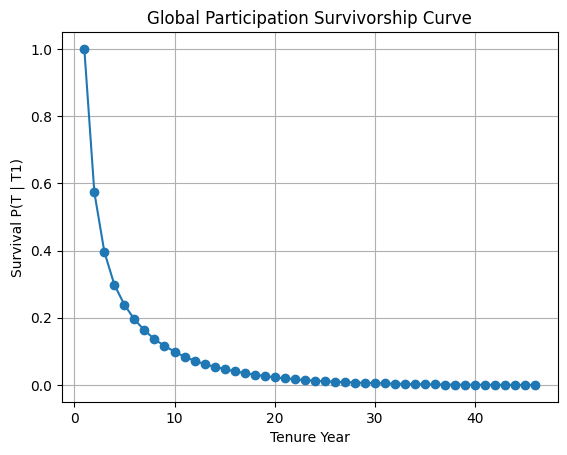

In [ ]:
plt.figure()
plt.plot(survival_participation["Tenure"], survival_participation["BaseSurvival"], marker="o")
plt.xlabel("Tenure Year")
plt.ylabel("Survival P(T | T1)")
plt.title("Global Participation Survivorship Curve")
plt.grid(True)
plt.show()


#### Dollar survivorship (fundraising)

In [ ]:
# Total fundraising per tenure (pooled across cohorts)
tenure_funds = cohort_tenure_funds.sum(axis=0)
tenure_funds = tenure_funds[tenure_funds > 0]

# Dollar base index: Fundraising_t / Fundraising_1
dollar_survival_base = tenure_funds / tenure_funds.iloc[0]

survival_dollars = pd.DataFrame({
    "Tenure": tenure_funds.index.astype(int),
    "TotalFunds": tenure_funds.values,
    "DollarBaseIndex": dollar_survival_base.values,
})

print("Dollar survivorship (pooled):")
display(survival_dollars)


Dollar survivorship (pooled):


,Tenure,TotalFunds,DollarBaseIndex
0,1,1.787934e+08,1.000000
1,2,1.134405e+08,0.634478
2,3,9.101707e+07,0.509063
3,4,7.282178e+07,0.407296
4,5,6.476837e+07,0.362252
5,6,5.564986e+07,0.311252
6,7,4.959131e+07,0.277366
7,8,4.429483e+07,0.247743
8,9,4.063182e+07,0.227256
9,10,3.764736e+07,0.210563


#### Plot dollar survivorship

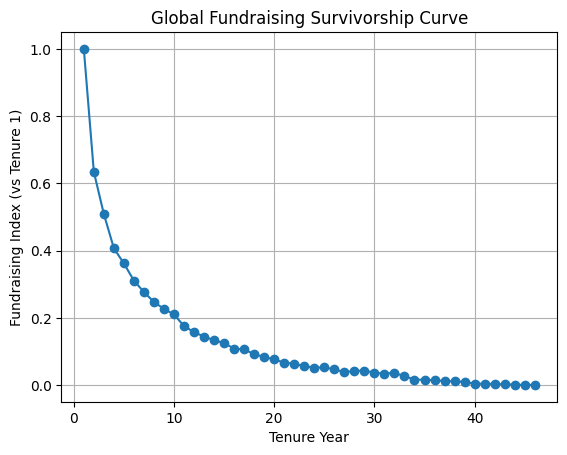

In [ ]:
plt.figure()
plt.plot(survival_dollars["Tenure"], survival_dollars["DollarBaseIndex"], marker="o")
plt.xlabel("Tenure Year")
plt.ylabel("Fundraising Index (vs Tenure 1)")
plt.title("Global Fundraising Survivorship Curve")
plt.grid(True)
plt.show()


# LTV Calculation

#### Helper functions for LTV

In [ ]:
# 1. Build global / segment-level LTV tables from cohort matrices
def build_global_ltv_from_cohorts(
    cohort_counts: pd.DataFrame,
    cohort_funds: pd.DataFrame,
    cohort_min_year: int | None = None,
    discount_rate: float = 0.0
) -> pd.DataFrame:
    """
    Build a global tenure-based LTV table using pooled cohorts.

    Returns a DataFrame with columns:
      Tenure, Riders, Survival_P_T_given_T1, AvgFund,
      EV_no_discount, DiscountFactor, EV_discounted
    and attrs["LTV_no_discount"], attrs["LTV_discounted"].
    """
    counts = cohort_counts.copy()
    funds  = cohort_funds.copy()

    if cohort_min_year is not None:
        counts = counts.loc[counts.index >= cohort_min_year]
        funds  = funds.loc[funds.index >= cohort_min_year]

    riders_by_tenure = counts.sum(axis=0)
    funds_by_tenure  = funds.sum(axis=0)

    riders_by_tenure = riders_by_tenure[riders_by_tenure > 0]
    funds_by_tenure  = funds_by_tenure.reindex(riders_by_tenure.index).fillna(0.0)

    avg_fund_by_tenure = funds_by_tenure / riders_by_tenure.replace(0, pd.NA)

    t1 = riders_by_tenure.index.min()
    survival_base = riders_by_tenure / riders_by_tenure.loc[t1]

    ev_no_disc = avg_fund_by_tenure * survival_base

    tenures = riders_by_tenure.index.astype(int)
    discount_factors = 1.0 / np.power(1 + discount_rate, tenures - tenures.min())
    ev_disc = ev_no_disc * discount_factors

    ltv_table = pd.DataFrame({
        "Tenure": tenures,
        "Riders": riders_by_tenure.values,
        "Survival_P_T_given_T1": survival_base.values,
        "AvgFund": avg_fund_by_tenure.values,
        "EV_no_discount": ev_no_disc.values,
        "DiscountFactor": discount_factors,
        "EV_discounted": ev_disc.values,
    })

    ltv_table.attrs["LTV_no_discount"] = float(ev_no_disc.sum(skipna=True))
    ltv_table.attrs["LTV_discounted"]  = float(ev_disc.sum(skipna=True))
    ltv_table.attrs["cohort_min_year"] = cohort_min_year
    ltv_table.attrs["discount_rate"]   = discount_rate

    return ltv_table


In [ ]:
# 2. For conditional LTV & survival stats from an LTV table
def compute_conditional_ltv(ltv_table: pd.DataFrame):
    """
    Given an LTV table (Tenure rows), compute:
      - P_survive_T2
      - P_survive_T3
      - Future_LTV_given_T2 (sum EV_t>=2 / P(T2))
      - Total_LTV_given_T2 (Year1 + future)
    """
    df = ltv_table

    def get_val(tenure, col):
        match = df.loc[df["Tenure"] == tenure, col]
        return float(match.iloc[0]) if len(match) > 0 else np.nan

    p_t2 = get_val(2, "Survival_P_T_given_T1")
    p_t3 = get_val(3, "Survival_P_T_given_T1")
    avg_y1 = get_val(1, "AvgFund")

    ev_from_t2 = df.loc[df["Tenure"] >= 2, "EV_no_discount"].sum()

    if p_t2 and p_t2 > 0:
        future_ltv_given_t2 = ev_from_t2 / p_t2
        total_ltv_given_t2 = avg_y1 + future_ltv_given_t2
    else:
        future_ltv_given_t2 = np.nan
        total_ltv_given_t2 = np.nan

    return {
        "P_Survive_to_T2": p_t2,
        "P_Survive_to_T3": p_t3,
        "Future_LTV_given_T2": future_ltv_given_t2,
        "Total_LTV_given_T2": total_ltv_given_t2,
    }


In [ ]:
# 3. Scenario: bump Year-2 survival by an absolute amount (+0.02, +0.05, etc.)
def retention_scenario_ltv(ltv_table: pd.DataFrame, delta_p2_abs: float) -> float:
    """
    Simple scenario: increase Tenure-2 survival P(T2|T1) by an absolute delta (e.g. +0.02).
    We scale the entire survival curve from Tenure>=2 upward by a constant factor.
    Returns the new unconditional LTV (no discount).
    """
    df = ltv_table.set_index("Tenure")

    surv = df["Survival_P_T_given_T1"].copy()
    avg  = df["AvgFund"].copy()

    if 2 not in surv.index or surv.loc[2] <= 0:
        return np.nan

    old_p2 = surv.loc[2]
    new_p2 = min(old_p2 + delta_p2_abs, 1.0)
    factor = new_p2 / old_p2

    new_surv = surv.copy()
    new_surv.loc[new_surv.index >= 2] = (new_surv.loc[new_surv.index >= 2] * factor).clip(upper=1.0)

    ev_new = new_surv * avg
    return float(ev_new.sum(skipna=True))

In [ ]:
#### Gordon Growth calculator for comparison

In [ ]:
# 4. Add Gordon-style tail to an LTV table
def add_gordon_tail_to_ltv(
    ltv_table: pd.DataFrame,
    terminal_start: int = 11,
    window_start: int = 4,
    window_end: int = 8,
):
    """
    Adds a Gordon-growth smoothed tail to the existing LTV table.

    Produces new columns:
      - EV_no_discount_empirical (same as EV_no_discount)
      - EV_no_discount_GG (empirical up to terminal_start, geometric tail afterwards)
      - EV_no_discount_diff (GG minus empirical)

    Also appends a 'Total' row showing both total empirical and smoothed LTV.
    """

    df = ltv_table.copy()

    # Make sure Tenure is numeric where possible
    df["Tenure"] = pd.to_numeric(df["Tenure"], errors="coerce")

    # Drop any 'Total' rows from prior runs
    df = df[df["Tenure"].notna()].copy()

    df = df.set_index("Tenure")

    ev_emp = df["EV_no_discount"].astype(float)
    surv   = df["Survival_P_T_given_T1"].astype(float)
    avg    = df["AvgFund"].astype(float)

    # ----- estimate decay factor k from mid-tenure window -----
    ws = max(window_start, int(df.index.min()))
    we = min(window_end,   int(df.index.max()) - 1)

    k_values = []
    for t in range(ws, we + 1):
        if t in surv.index and (t + 1) in surv.index:
            surv_t, surv_next = surv.loc[t], surv.loc[t + 1]
            avg_t, avg_next   = avg.loc[t],  avg.loc[t + 1]
            if surv_t > 0 and avg_t > 0:
                ev_t = surv_t * avg_t
                ev_next = surv_next * avg_next
                if ev_t > 0:
                    k_values.append(ev_next / ev_t)

    if not k_values:
        df["EV_no_discount_empirical"] = ev_emp
        df["EV_no_discount_GG"] = ev_emp
        df["EV_no_discount_diff"] = 0.0
        return df.reset_index()

    k = float(np.mean(k_values))

    # ----- build Gordon-smoothed EV series -----
    ev_gg = ev_emp.copy()
    if terminal_start in ev_gg.index:
        start_val = ev_emp.loc[terminal_start]
        tail_tenures = sorted(t for t in ev_gg.index if t > terminal_start)
        for i, t in enumerate(tail_tenures, start=1):
            ev_gg.loc[t] = start_val * (k ** i)

    # ----- add columns + Total row -----
    df["EV_no_discount_empirical"] = ev_emp
    df["EV_no_discount_GG"] = ev_gg
    df["EV_no_discount_diff"] = df["EV_no_discount_GG"] - df["EV_no_discount_empirical"]

    total_emp = float(ev_emp.sum())
    total_gg  = float(ev_gg.sum())

    total_row = pd.DataFrame({
        "Tenure": ["Total"],
        "Riders": [np.nan],
        "Survival_P_T_given_T1": [np.nan],
        "AvgFund": [np.nan],
        "EV_no_discount": [np.nan],
        "DiscountFactor": [np.nan],
        "EV_discounted": [np.nan],
        "EV_no_discount_empirical": [total_emp],
        "EV_no_discount_GG": [total_gg],
        "EV_no_discount_diff": [total_gg - total_emp],
    })

    df_out = df.reset_index()
    df_out = pd.concat([df_out, total_row], ignore_index=True)

    df_out.attrs["LTV_empirical_sum"] = total_emp
    df_out.attrs["LTV_GG_sum"] = total_gg
    df_out.attrs["Gordon_k"] = k

    return df_out

In [ ]:
#### LTV calculator; full tenure and last 20 years

In [ ]:
# Full-history LTV (all cohorts)
ltv_global_full = build_global_ltv_from_cohorts(
    cohort_tenure_counts,
    cohort_tenure_funds,
    cohort_min_year=None,       # no filter
    discount_rate=0.0           # baseline: no discount
)

print("Full-history LTV (no discount):", ltv_global_full.attrs["LTV_no_discount"])
display(ltv_global_full.head(15))

# Modern-era LTV (cohorts 2005+)
ltv_global_modern = build_global_ltv_from_cohorts(
    cohort_tenure_counts,
    cohort_tenure_funds,
    cohort_min_year=2005,       # limit to last 20 years
    discount_rate=0.0
)

print("Modern-era LTV (cohorts >=2005, no discount):", ltv_global_modern.attrs["LTV_no_discount"])
display(ltv_global_modern.head(15))


Full-history LTV (no discount): 23865.16903707865


,Tenure,Riders,Survival_P_T_given_T1,AvgFund,EV_no_discount,DiscountFactor,EV_discounted
0,1,45746,1.000000,3908.395114,3908.395114,1.0,3908.395114
1,2,26219,0.573143,4326.652511,2479.790631,1.0,2479.790631
2,3,18112,0.395925,5025.235542,1989.618024,1.0,1989.618024
3,4,13637,0.298103,5340.014315,1591.871971,1.0,1591.871971
4,5,10913,0.238556,5934.973759,1415.825835,1.0,1415.825835
5,6,8925,0.195099,6235.278613,1216.496778,1.0,1216.496778
6,7,7436,0.162550,6669.084161,1084.057837,1.0,1084.057837
7,8,6233,0.136252,7106.503104,968.277748,1.0,968.277748
8,9,5305,0.115966,7659.155078,888.204820,1.0,888.204820
9,10,4549,0.099440,8275.963447,822.965018,1.0,822.965018


Modern-era LTV (cohorts >=2005, no discount): 19509.55163170811


,Tenure,Riders,Survival_P_T_given_T1,AvgFund,EV_no_discount,DiscountFactor,EV_discounted
0,1,33616,1.000000,4445.761960,4445.761960,1.0,4445.761960
1,2,18179,0.540784,4947.033427,2675.277269,1.0,2675.277269
2,3,11952,0.355545,5853.461082,2081.168695,1.0,2081.168695
3,4,8735,0.259847,6057.909345,1574.126551,1.0,1574.126551
4,5,6804,0.202404,6605.728110,1337.023265,1.0,1337.023265
5,6,5462,0.162482,7040.429574,1143.944144,1.0,1143.944144
6,7,4485,0.133419,7467.479008,996.300671,1.0,996.300671
7,8,3628,0.107925,8089.327492,873.039033,1.0,873.039033
8,9,2982,0.088708,8729.155248,774.343793,1.0,774.343793
9,10,2447,0.072793,9777.575018,711.736259,1.0,711.736259


#### Visual by tenure

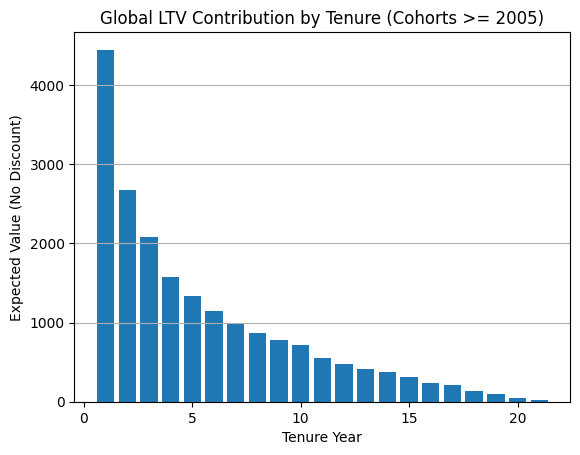

In [ ]:
import matplotlib.pyplot as plt

def plot_ltv_curve(ltv_table, title="LTV by Tenure"):
    plt.figure()
    plt.bar(ltv_table["Tenure"], ltv_table["EV_no_discount"])
    plt.xlabel("Tenure Year")
    plt.ylabel("Expected Value (No Discount)")
    plt.title(title)
    plt.grid(True, axis="y")
    plt.show()

plot_ltv_curve(ltv_global_modern, title="Global LTV Contribution by Tenure (Cohorts >= 2005)")


#### Helper function for global LTV table

In [ ]:
import numpy as np
import pandas as pd

def build_global_ltv_from_cohorts(
    cohort_counts: pd.DataFrame,
    cohort_funds: pd.DataFrame,
    cohort_min_year: int | None = None,
    discount_rate: float = 0.0
) -> pd.DataFrame:
    """
    Build a global tenure-based LTV table using pooled cohorts.

    Parameters
    ----------
    cohort_counts : DataFrame
        Index = CohortYear, Columns = Tenure (1,2,3,...)
    cohort_funds : DataFrame
        Same shape, total fundraising values.
    cohort_min_year : int or None
        If not None, restrict to cohorts >= this year (e.g., 2005)
    discount_rate : float
        Annual discount rate (0.0 = no discount)

    Returns
    -------
    DataFrame with columns:
        Tenure
        Riders
        Survival_P_T_given_T1
        AvgFund
        EV_no_discount
        DiscountFactor
        EV_discounted
    """
    counts = cohort_counts.copy()
    funds  = cohort_funds.copy()

    # Restrict to modern cohorts if specified
    if cohort_min_year is not None:
        counts = counts.loc[counts.index >= cohort_min_year]
        funds  = funds.loc[funds.index >= cohort_min_year]

    # Aggregate across all included cohorts
    riders_by_tenure = counts.sum(axis=0)         # Number of riders in each tenure
    funds_by_tenure  = funds.sum(axis=0)          # Total fundraising in each tenure
    riders_by_tenure = riders_by_tenure[riders_by_tenure > 0]
    funds_by_tenure  = funds_by_tenure.reindex(riders_by_tenure.index).fillna(0.0)

    # Average fundraising per rider at each tenure
    avg_fund_by_tenure = funds_by_tenure / riders_by_tenure.replace(0, pd.NA)

    # Base survival curve P(T | T1)
    t1 = riders_by_tenure.index.min()
    survival_base = riders_by_tenure / riders_by_tenure.loc[t1]

    # Expected value (no discount)
    ev_no_disc = avg_fund_by_tenure * survival_base

    # Discount factor (Tenure 1 = year 0 exponent)
    tenures = riders_by_tenure.index.astype(int)
    discount_factors = 1.0 / np.power(1 + discount_rate, tenures - tenures.min())

    ev_disc = ev_no_disc * discount_factors

    # Build output DataFrame
    ltv_table = pd.DataFrame({
        "Tenure": tenures,
        "Riders": riders_by_tenure.values,
        "Survival_P_T_given_T1": survival_base.values,
        "AvgFund": avg_fund_by_tenure.values,
        "EV_no_discount": ev_no_disc.values,
        "DiscountFactor": discount_factors,
        "EV_discounted": ev_disc.values,
    })

    # Attach summary values
    ltv_table.attrs["LTV_no_discount"] = float(ev_no_disc.sum(skipna=True))
    ltv_table.attrs["LTV_discounted"]  = float(ev_disc.sum(skipna=True))
    ltv_table.attrs["cohort_min_year"] = cohort_min_year
    ltv_table.attrs["discount_rate"]   = discount_rate

    return ltv_table


#### Full history LTV

In [ ]:
## Main Weekend Rider-Year Table

In [ ]:
# 1. Define which segments count as Main Weekend
main_segments = ["Core - Main", "Non-Core - Main"]

# 2. Convert seg_matrix (wide) to long format: Main_ID, EventYear, Segment
seg_long = (
    seg_matrix
    .stack()
    .reset_index()
    .rename(columns={"level_1": "EventYear", 0: "Segment"})
)

# Ensure EventYear numeric (should already be, but just in case)
seg_long["EventYear"] = pd.to_numeric(seg_long["EventYear"], errors="coerce")

# 3. Join segment info onto global rider-year table
df_ry_main = df_ry.merge(
    seg_long,
    on=["Main_ID", "EventYear"],
    how="left"
)

# 4. Keep only Main Weekend years (Core or Non-Core)
df_ry_main = df_ry_main[df_ry_main["Segment"].isin(main_segments)].copy()

print("Main Weekend rider-year rows:", df_ry_main.shape[0])
display(df_ry_main.head())


Main Weekend rider-year rows: 150559


,Main_ID,EventYear,any_pmc,Total Raised,CohortYear,Tenure,Segment
0,00001-3,1986,1,0.0,1986,1,Non-Core - Main
1,00001-3,1987,1,0.0,1986,2,Non-Core - Main
2,00001-3,1988,1,0.0,1986,3,Non-Core - Main
3,00001-3,1989,1,580.0,1986,4,Non-Core - Main
4,00002-6,1989,1,316.0,1989,1,Non-Core - Main


#### Assign main weekend cohort and main tenure

In [ ]:
# CohortYear_Main = first year they ever rode Main Weekend
cohort_main = (
    df_ry_main
    .groupby("Main_ID")["EventYear"]
    .min()
    .rename("CohortYear_Main")
)

df_ry_main = df_ry_main.merge(cohort_main, on="Main_ID", how="left")

# Tenure_Main = 1,2,3,... counting only Main Weekend participations
df_ry_main = df_ry_main.sort_values(["Main_ID", "EventYear"])

df_ry_main["Tenure_Main"] = (
    df_ry_main
    .groupby("Main_ID")["EventYear"]
    .rank(method="first")
    .astype(int)
)

print("Main Weekend rider-year with cohort/tenure:")
display(df_ry_main.head(10))


Main Weekend rider-year with cohort/tenure:


,Main_ID,EventYear,any_pmc,Total Raised,CohortYear,Tenure,Segment,CohortYear_Main,Tenure_Main
0,00001-3,1986,1,0.00,1986,1,Non-Core - Main,1986,1
1,00001-3,1987,1,0.00,1986,2,Non-Core - Main,1986,2
2,00001-3,1988,1,0.00,1986,3,Non-Core - Main,1986,3
3,00001-3,1989,1,580.00,1986,4,Non-Core - Main,1986,4
4,00002-6,1989,1,316.00,1989,1,Non-Core - Main,1989,1
5,00003-9,1991,1,912.61,1991,1,Non-Core - Main,1991,1
6,00004-2,1990,1,800.00,1990,1,Non-Core - Main,1990,1
7,00004-2,1999,1,2921.20,1990,2,Non-Core - Main,1990,2
8,00005-5,1987,1,0.00,1987,1,Non-Core - Main,1987,1
9,00005-5,1988,1,0.00,1987,2,Non-Core - Main,1987,2


#### Build main weekend cohort x tenure tables

In [ ]:
# Rider counts per Main Weekend cohort × tenure
cohort_tenure_counts_main = (
    df_ry_main
    .pivot_table(
        index="CohortYear_Main",
        columns="Tenure_Main",
        values="Main_ID",
        aggfunc="nunique",
        fill_value=0
    )
    .sort_index()
)

print("Main Weekend Cohort × Tenure – Rider Counts")
display(cohort_tenure_counts_main)

# Total fundraising per Main Weekend cohort × tenure
cohort_tenure_funds_main = (
    df_ry_main
    .pivot_table(
        index="CohortYear_Main",
        columns="Tenure_Main",
        values=FUNDRAISING_COL,   # same total per rider/year
        aggfunc="sum",
        fill_value=0.0
    )
    .sort_index()
)

print("Main Weekend Cohort × Tenure – Total Fundraising")
display(cohort_tenure_funds_main)

# Average fundraising per rider for Main Weekend
aligned_counts_main, aligned_funds_main = cohort_tenure_counts_main.align(
    cohort_tenure_funds_main,
    join="outer",
    fill_value=0
)

avg_fundraising_tenure_main = aligned_funds_main / aligned_counts_main.replace(0, pd.NA)

print("Main Weekend Cohort × Tenure – Avg Fundraising per Rider")
display(avg_fundraising_tenure_main)


Main Weekend Cohort × Tenure – Rider Counts


Tenure_Main,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear_Main,,,,,,,,,,,,,,,,,,,,,
1980,9,9,9,9,9,9,9,9,9,9,...,4,4,4,4,4,4,3,3,3,1
1981,15,14,13,13,13,13,13,13,13,12,...,3,3,2,2,2,2,1,1,1,0
1982,21,21,20,20,20,19,18,17,17,16,...,3,2,2,1,1,1,1,1,0,0
1983,27,26,25,24,23,23,21,17,16,16,...,2,2,2,2,2,1,1,0,0,0
1984,38,38,38,37,37,33,26,23,20,18,...,3,3,2,2,1,0,0,0,0,0
1985,62,61,61,60,52,46,40,38,34,30,...,7,7,6,5,4,0,0,0,0,0
1986,95,95,95,85,71,58,48,42,41,38,...,7,6,6,4,0,0,0,0,0,0
1987,191,191,164,121,107,83,73,66,55,50,...,6,6,2,0,0,0,0,0,0,0
1988,36,36,35,34,34,34,33,33,33,32,...,4,4,0,0,0,0,0,0,0,0


Main Weekend Cohort × Tenure – Total Fundraising


Tenure_Main,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear_Main,,,,,,,,,,,,,,,,,,,,,
1980,2.850000e+03,3.850000e+03,8.040000e+03,1.143500e+04,9.714000e+03,1.319500e+04,1.486500e+04,1.456500e+04,1.785800e+04,2.330800e+04,...,117718.37,195813.80,163408.26,111078.25,157933.95,171567.28,173116.56,178788.0,200742.25,172848.52
1981,8.846000e+03,1.343140e+04,1.459300e+04,2.132542e+04,2.666318e+04,3.492040e+04,3.772600e+04,4.349400e+04,6.971550e+04,5.983040e+04,...,124053.00,136780.00,153383.00,121020.00,224310.00,195916.00,13310.00,12250.5,13868.61,0.00
1982,7.000000e+02,5.750000e+03,1.285000e+03,8.994000e+03,9.740000e+03,5.545000e+03,4.741000e+03,2.190100e+04,2.152996e+04,2.235420e+04,...,23484.00,29071.00,35052.00,40037.00,41209.88,42269.00,55224.20,80203.0,0.00,0.00
1983,0.000000e+00,1.216821e+04,5.150000e+03,2.495380e+03,2.230000e+03,2.111700e+03,4.607399e+04,4.527150e+04,4.759850e+04,5.939550e+04,...,168968.00,236080.00,271120.00,281120.00,184075.09,10867.08,11933.09,0.0,0.00,0.00
1984,6.000000e+03,9.700000e+03,1.529000e+04,1.547600e+04,1.584400e+04,6.129859e+04,9.278350e+04,1.070048e+05,8.550084e+04,8.191000e+04,...,223949.63,189605.29,80098.76,62289.96,52664.34,0.00,0.00,0.0,0.00,0.00
1985,1.730000e+03,1.098533e+04,7.659000e+03,1.311250e+04,1.071060e+05,1.121709e+05,1.116180e+05,1.165708e+05,1.162772e+05,1.196168e+05,...,114197.10,108974.43,63162.85,43532.10,44922.33,0.00,0.00,0.0,0.00,0.00
1986,7.782500e+03,1.052300e+04,1.427100e+04,1.145196e+05,1.202073e+05,1.133409e+05,1.174872e+05,1.138228e+05,1.183768e+05,1.178472e+05,...,176861.29,172156.44,166410.74,135559.49,0.00,0.00,0.00,0.0,0.00,0.00
1987,6.984000e+03,2.058900e+04,2.349564e+05,2.138327e+05,2.221542e+05,1.780663e+05,1.842262e+05,1.856061e+05,1.816796e+05,2.205434e+05,...,948735.24,689150.32,614263.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
1988,1.079600e+04,5.876507e+04,7.421318e+04,9.004872e+04,9.955439e+04,1.404936e+05,1.417072e+05,1.513967e+05,1.562743e+05,1.682101e+05,...,149494.03,149719.18,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00


Main Weekend Cohort × Tenure – Avg Fundraising per Rider


Tenure_Main,1,2,3,4,5,6,7,8,9,10,...,37,38,39,40,41,42,43,44,45,46
CohortYear_Main,,,,,,,,,,,,,,,,,,,,,
1980,316.666667,427.777778,893.333333,1270.555556,1079.333333,1466.111111,1651.666667,1618.333333,1984.222222,2589.777778,...,29429.5925,48953.45,40852.065,27769.5625,39483.4875,42891.82,57705.52,59596.0,66914.083333,172848.52
1981,589.733333,959.385714,1122.538462,1640.416923,2051.013846,2686.184615,2902.0,3345.692308,5362.730769,4985.866667,...,41351.0,45593.333333,76691.5,60510.0,112155.0,97958.0,13310.0,12250.5,13868.61,<NA>
1982,33.333333,273.809524,64.25,449.7,487.0,291.842105,263.388889,1288.294118,1266.468235,1397.1375,...,7828.0,14535.5,17526.0,40037.0,41209.88,42269.0,55224.2,80203.0,<NA>,<NA>
1983,0.000000,468.008077,206.0,103.974167,96.956522,91.813043,2193.999524,2663.029412,2974.90625,3712.21875,...,84484.0,118040.0,135560.0,140560.0,92037.545,10867.08,11933.09,<NA>,<NA>,<NA>
1984,157.894737,255.263158,402.368421,418.27027,428.216216,1857.53303,3568.596154,4652.382609,4275.042,4550.555556,...,74649.876667,63201.763333,40049.38,31144.98,52664.34,<NA>,<NA>,<NA>,<NA>,<NA>
1985,27.903226,180.087377,125.557377,218.541667,2059.731346,2438.498478,2790.45,3067.653421,3419.917647,3987.226667,...,16313.871429,15567.775714,10527.141667,8706.42,11230.5825,<NA>,<NA>,<NA>,<NA>,<NA>
1986,81.921053,110.768421,150.221053,1347.288824,1693.060986,1954.153966,2447.650417,2710.065952,2887.237805,3101.241316,...,25265.898571,28692.74,27735.123333,33889.8725,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1987,36.565445,107.795812,1432.660732,1767.212149,2076.207103,2145.376867,2523.64726,2812.213939,3303.265455,4410.8688,...,158122.54,114858.386667,307131.5,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1988,299.888889,1632.363056,2120.376571,2648.491765,2928.070294,4132.163824,4294.158182,4587.778788,4735.583939,5256.565625,...,37373.5075,37429.795,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [ ]:
# === BASE LTV TABLES (pure empirical, no Gordon tail yet) ===

# Global – full history
ltv_global_full_base = build_global_ltv_from_cohorts(
    cohort_tenure_counts,
    cohort_tenure_funds,
    cohort_min_year=None,
    discount_rate=0.0,
)

# Global – modern era (cohorts >= 2005)
ltv_global_modern_base = build_global_ltv_from_cohorts(
    cohort_tenure_counts,
    cohort_tenure_funds,
    cohort_min_year=2005,
    discount_rate=0.0,
)

# Main Weekend – full history
ltv_main_full_base = build_global_ltv_from_cohorts(
    cohort_tenure_counts_main,
    cohort_tenure_funds_main,
    cohort_min_year=None,
    discount_rate=0.0,
)

# Main Weekend – modern era (cohorts >= 2005)
ltv_main_modern_base = build_global_ltv_from_cohorts(
    cohort_tenure_counts_main,
    cohort_tenure_funds_main,
    cohort_min_year=2005,
    discount_rate=0.0,
)

print("Global full LTV:",  ltv_global_full_base.attrs["LTV_no_discount"])
print("Global modern LTV:", ltv_global_modern_base.attrs["LTV_no_discount"])
print("Main full LTV:",     ltv_main_full_base.attrs["LTV_no_discount"])
print("Main modern LTV:",   ltv_main_modern_base.attrs["LTV_no_discount"])

Global full LTV: 23865.16903707865
Global modern LTV: 19509.55163170811
Main full LTV: 26164.78972438993
Main modern LTV: 22568.140031699604


#### Add in the Gordon Growth LTV calculations for comparison

In [ ]:
# === AUGMENTED TABLES WITH GORDON TAIL (for Excel visualization) ===

ltv_global_modern = add_gordon_tail_to_ltv(
    ltv_global_modern_base,
    terminal_start=11,
    window_start=4,
    window_end=8,
)

ltv_main_modern = add_gordon_tail_to_ltv(
    ltv_main_modern_base,
    terminal_start=11,
    window_start=4,
    window_end=8,
)

# (Optional: you can also apply add_gordon_tail_to_ltv to the full-history tables if desired)
# ltv_global_full = add_gordon_tail_to_ltv(ltv_global_full_base, ...)
# ltv_main_full   = add_gordon_tail_to_ltv(ltv_main_full_base, ...)

## Compute main weekend LTV (full + '05+)

In [ ]:
# Full-history Main Weekend LTV (no discount)
ltv_main_full = build_global_ltv_from_cohorts(
    cohort_tenure_counts_main,
    cohort_tenure_funds_main,
    cohort_min_year=None,
    discount_rate=0.0
)

print("Main Weekend LTV – Full history (no discount):", ltv_main_full.attrs["LTV_no_discount"])
display(ltv_main_full.head(20))

# Modern-era Main Weekend LTV (cohorts >= 2005)
ltv_main_modern = build_global_ltv_from_cohorts(
    cohort_tenure_counts_main,
    cohort_tenure_funds_main,
    cohort_min_year=2005,
    discount_rate=0.0
)

print("Main Weekend LTV – Cohorts >=2005 (no discount):", ltv_main_modern.attrs["LTV_no_discount"])
display(ltv_main_modern.head(20))


Main Weekend LTV – Full history (no discount): 26164.78972438993


,Tenure,Riders,Survival_P_T_given_T1,AvgFund,EV_no_discount,DiscountFactor,EV_discounted
0,1,38930,1.000000,4409.174544,4409.174544,1.0,4409.174544
1,2,22764,0.584742,4806.712982,2810.686214,1.0,2810.686214
2,3,16018,0.411456,5465.897625,2248.978889,1.0,2248.978889
3,4,12100,0.310814,5770.097423,1793.428688,1.0,1793.428688
4,5,9644,0.247727,6280.098315,1555.747962,1.0,1555.747962
5,6,7820,0.200873,6768.594837,1359.630404,1.0,1359.630404
6,7,6463,0.166016,7256.908885,1204.762449,1.0,1204.762449
7,8,5430,0.139481,7773.629114,1084.274495,1.0,1084.274495
8,9,4550,0.116876,8129.642587,950.163724,1.0,950.163724
9,10,3855,0.099024,8660.082493,857.555048,1.0,857.555048


Main Weekend LTV – Cohorts >=2005 (no discount): 22568.140031699604


,Tenure,Riders,Survival_P_T_given_T1,AvgFund,EV_no_discount,DiscountFactor,EV_discounted
0,1,26871,1.000000,5309.867684,5309.867684,1.0,5309.867684
1,2,14847,0.552529,5801.720716,3205.617486,1.0,3205.617486
2,3,10017,0.372781,6653.940478,2480.463018,1.0,2480.463018
3,4,7339,0.273120,6819.278443,1862.479420,1.0,1862.479420
4,5,5679,0.211343,7412.571210,1566.595657,1.0,1566.595657
5,6,4517,0.168099,7999.201405,1344.661261,1.0,1344.661261
6,7,3659,0.136169,8532.515945,1161.865053,1.0,1161.865053
7,8,2983,0.111012,9277.787369,1029.944540,1.0,1029.944540
8,9,2400,0.089316,9647.091579,861.635957,1.0,861.635957
9,10,1945,0.072383,10509.228679,760.688094,1.0,760.688094


# Output Generation

Export to Excel for translation into visual formats for presentation

#### 6. Export to Excel

##### LTV Summary Builder

In [ ]:
import numpy as np
import pandas as pd

def compute_conditional_ltv(ltv_table: pd.DataFrame):
    """
    Given an LTV table (Tenure rows), compute:
      - P_survive_T2
      - P_survive_T3
      - conditional future LTV given reach T2 (sum EV_t>=2 / P(T2))
      - total EV for rider who has reached T2 (Year1 + conditional future)
    Returns dict of metrics (may contain NaNs if Tenure 2/3 not present).
    """
    df = ltv_table

    def get_val(tenure, col):
        match = df.loc[df["Tenure"] == tenure, col]
        return float(match.iloc[0]) if len(match) > 0 else np.nan

    # Survival probs
    p_t2 = get_val(2, "Survival_P_T_given_T1")
    p_t3 = get_val(3, "Survival_P_T_given_T1")

    # Avg Year 1 fundraising
    avg_y1 = get_val(1, "AvgFund")

    # Future EV from T2 onward (unconditional)
    ev_from_t2 = df.loc[df["Tenure"] >= 2, "EV_no_discount"].sum()

    # Conditional future EV given reach T2
    if p_t2 and p_t2 > 0:
        future_ltv_given_t2 = ev_from_t2 / p_t2
        total_ltv_given_t2 = avg_y1 + future_ltv_given_t2
    else:
        future_ltv_given_t2 = np.nan
        total_ltv_given_t2 = np.nan

    return {
        "P_Survive_to_T2": p_t2,
        "P_Survive_to_T3": p_t3,
        "Future_LTV_given_T2": future_ltv_given_t2,
        "Total_LTV_given_T2": total_ltv_given_t2,
    }

# Build the summary output table
summary_rows = []

# ---------- Global: base metrics ----------

global_full_ltv   = ltv_global_full_base.attrs["LTV_no_discount"]
global_mod_ltv    = ltv_global_modern_base.attrs["LTV_no_discount"]
global_pct_diff   = (global_mod_ltv - global_full_ltv) / global_full_ltv if global_full_ltv else np.nan

global_mod_cond = compute_conditional_ltv(ltv_global_modern_base)

summary_rows.extend([
    {
        "Metric": "LTV (Unconditional, No Discount)",
        "Scope": "Global",
        "Cohorts": "All",
        "Scenario": "Base",
        "Value": global_full_ltv,
    },
    {
        "Metric": "LTV (Unconditional, No Discount)",
        "Scope": "Global",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": global_mod_ltv,
    },
    {
        "Metric": "LTV % Difference: Modern vs Full",
        "Scope": "Global",
        "Cohorts": ">=2005 vs All",
        "Scenario": "Base",
        "Value": global_pct_diff,
    },
    {
        "Metric": "P(Survive to Tenure 2)",
        "Scope": "Global",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": global_mod_cond["P_Survive_to_T2"],
    },
    {
        "Metric": "P(Survive to Tenure 3)",
        "Scope": "Global",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": global_mod_cond["P_Survive_to_T3"],
    },
    {
        "Metric": "Future LTV | Reach Tenure 2 (T2+ only)",
        "Scope": "Global",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": global_mod_cond["Future_LTV_given_T2"],
    },
    {
        "Metric": "Total LTV | Rider who reaches Tenure 2 (Y1 + future)",
        "Scope": "Global",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": global_mod_cond["Total_LTV_given_T2"],
    },
])

# ---------- Global: Y2 survival scenarios ----------

global_mod_ltv_y2p2 = retention_scenario_ltv(ltv_global_modern_base, delta_p2_abs=0.02)
global_uplift_2pt   = (global_mod_ltv_y2p2 - global_mod_ltv) / global_mod_ltv if global_mod_ltv else np.nan

global_mod_ltv_y2p5 = retention_scenario_ltv(ltv_global_modern_base, delta_p2_abs=0.05)
global_uplift_5pt   = (global_mod_ltv_y2p5 - global_mod_ltv) / global_mod_ltv if global_mod_ltv else np.nan

summary_rows.extend([
    {
        "Metric": "LTV (Unconditional, No Discount)",
        "Scope": "Global",
        "Cohorts": ">=2005",
        "Scenario": "+2 pts Y2 survival",
        "Value": global_mod_ltv_y2p2,
    },
    {
        "Metric": "LTV Uplift vs Base (%, +2 pts Y2)",
        "Scope": "Global",
        "Cohorts": ">=2005",
        "Scenario": "+2 pts Y2 survival",
        "Value": global_uplift_2pt,
    },
    {
        "Metric": "LTV (Unconditional, No Discount)",
        "Scope": "Global",
        "Cohorts": ">=2005",
        "Scenario": "+5 pts Y2 survival",
        "Value": global_mod_ltv_y2p5,
    },
    {
        "Metric": "LTV Uplift vs Base (%, +5 pts Y2)",
        "Scope": "Global",
        "Cohorts": ">=2005",
        "Scenario": "+5 pts Y2 survival",
        "Value": global_uplift_5pt,
    },
])

# ---------- Main Weekend: base metrics ----------

main_full_ltv = ltv_main_full_base.attrs["LTV_no_discount"]
main_mod_ltv  = ltv_main_modern_base.attrs["LTV_no_discount"]
main_pct_diff = (main_mod_ltv - main_full_ltv) / main_full_ltv if main_full_ltv else np.nan

main_mod_cond = compute_conditional_ltv(ltv_main_modern_base)

summary_rows.extend([
    {
        "Metric": "LTV (Unconditional, No Discount)",
        "Scope": "Main Weekend",
        "Cohorts": "All",
        "Scenario": "Base",
        "Value": main_full_ltv,
    },
    {
        "Metric": "LTV (Unconditional, No Discount)",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": main_mod_ltv,
    },
    {
        "Metric": "LTV % Difference: Modern vs Full",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005 vs All",
        "Scenario": "Base",
        "Value": main_pct_diff,
    },
    {
        "Metric": "P(Survive to Tenure 2)",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": main_mod_cond["P_Survive_to_T2"],
    },
    {
        "Metric": "P(Survive to Tenure 3)",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": main_mod_cond["P_Survive_to_T3"],
    },
    {
        "Metric": "Future LTV | Reach Tenure 2 (T2+ only)",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": main_mod_cond["Future_LTV_given_T2"],
    },
    {
        "Metric": "Total LTV | Rider who reaches Tenure 2 (Y1 + future)",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005",
        "Scenario": "Base",
        "Value": main_mod_cond["Total_LTV_given_T2"],
    },
])

# ---------- Main Weekend: Y2 survival scenarios ----------

main_mod_ltv_y2p2 = retention_scenario_ltv(ltv_main_modern_base, delta_p2_abs=0.02)
main_uplift_2pt   = (main_mod_ltv_y2p2 - main_mod_ltv) / main_mod_ltv if main_mod_ltv else np.nan

main_mod_ltv_y2p5 = retention_scenario_ltv(ltv_main_modern_base, delta_p2_abs=0.05)
main_uplift_5pt   = (main_mod_ltv_y2p5 - main_mod_ltv) / main_mod_ltv if main_mod_ltv else np.nan

summary_rows.extend([
    {
        "Metric": "LTV (Unconditional, No Discount)",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005",
        "Scenario": "+2 pts Y2 survival",
        "Value": main_mod_ltv_y2p2,
    },
    {
        "Metric": "LTV Uplift vs Base (%, +2 pts Y2)",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005",
        "Scenario": "+2 pts Y2 survival",
        "Value": main_uplift_2pt,
    },
    {
        "Metric": "LTV (Unconditional, No Discount)",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005",
        "Scenario": "+5 pts Y2 survival",
        "Value": main_mod_ltv_y2p5,
    },
    {
        "Metric": "LTV Uplift vs Base (%, +5 pts Y2)",
        "Scope": "Main Weekend",
        "Cohorts": ">=2005",
        "Scenario": "+5 pts Y2 survival",
        "Value": main_uplift_5pt,
    },
])

ltv_output = pd.DataFrame(summary_rows)

print("LTV Output Summary:")
display(ltv_output)



LTV Output Summary:


,Metric,Scope,Cohorts,Scenario,Value
0,"LTV (Unconditional, No Discount)",Global,All,Base,23865.169037
1,"LTV (Unconditional, No Discount)",Global,>=2005,Base,19509.551632
2,LTV % Difference: Modern vs Full,Global,>=2005 vs All,Base,-0.182509
3,P(Survive to Tenure 2),Global,>=2005,Base,0.540784
4,P(Survive to Tenure 3),Global,>=2005,Base,0.355545
5,Future LTV | Reach Tenure 2 (T2+ only),Global,>=2005,Base,27855.457044
6,Total LTV | Rider who reaches Tenure 2 (Y1 + f...,Global,>=2005,Base,32301.219004
7,"LTV (Unconditional, No Discount)",Global,>=2005,+2 pts Y2 survival,20066.660773
8,"LTV Uplift vs Base (%, +2 pts Y2)",Global,>=2005,+2 pts Y2 survival,0.028556
9,"LTV (Unconditional, No Discount)",Global,>=2005,+5 pts Y2 survival,20902.324484


#Executive Stats

In [ ]:
# --- CONFIG: adjust these names if needed ---
YEAR_TARGET        = 2025
CORE_SEGMENT_LABEL = "Core - Main"   # how Core routes appear in seg_matrix

# IMPORTANT: do NOT re-define FUNDRAISING_COL here.
# It should already be defined earlier, e.g. FUNDRAISING_COL = "Total Raised"

STATE_COL   = "State"    # home state column in df (if available)
AGE_COL     = "Age"      # age as of 2025 (if available)
GENDER_COL  = "Gender"   # gender column in df (if available)
TENURE_COL  = "Tenure"   # tenure in df_ry


# ---------- 1. Base rider-year slice for 2025 ----------

# Start from global rider-year table
df_2025 = df_ry[df_ry["EventYear"] == YEAR_TARGET].copy()

# Attach 2025 segment from seg_matrix (this is where "Core - Main" lives)
if YEAR_TARGET in seg_matrix.columns:
    seg2025 = (
        seg_matrix[[YEAR_TARGET]]
        .rename(columns={YEAR_TARGET: "Segment2025"})
        .reset_index()
    )
    df_2025 = df_2025.merge(seg2025, on="Main_ID", how="left")
    df_2025["is_core"] = df_2025["Segment2025"].eq(CORE_SEGMENT_LABEL)
else:
    df_2025["Segment2025"] = np.nan
    df_2025["is_core"] = False

# Ensure one row per rider
df_2025 = (
    df_2025
    .sort_values(["Main_ID"])
    .drop_duplicates(subset="Main_ID", keep="first")
)

# ---------- 2. Lifetime fundraising through 2025 ----------

lifetime_funds = (
    df_ry[df_ry["EventYear"] <= YEAR_TARGET]
    .groupby("Main_ID")[FUNDRAISING_COL]
    .sum()
    .rename("LifetimeFunds")
    .reset_index()
)

df_2025 = df_2025.merge(lifetime_funds, on="Main_ID", how="left")

# ---------- 3. Attach demographics from df (if available) ----------

demo_aggs = {}
for col in [STATE_COL, AGE_COL, GENDER_COL]:
    if col in df.columns:
        demo_aggs[col] = "first"

if demo_aggs:
    demo = (
        df
        .groupby("Main_ID")
        .agg(demo_aggs)
        .reset_index()
    )
    df_2025 = df_2025.merge(demo, on="Main_ID", how="left")


# ---------- 4. Helper to compute summary stats for a segment ----------

def summarize_riders(df_scope, scope_label):
    """
    df_scope: one row per rider (2025 participants in the given segment set)
    scope_label: "Core Routes 2025" or "Global PMC 2025"
    """
    if df_scope.empty:
        return {
            "Scope": scope_label,
            "Participants_2025": 0,
            "Tenure_Median": np.nan,
            "Tenure_Average": np.nan,
            "LifetimeFunds_Median": np.nan,
            "LifetimeFunds_Average": np.nan,
            "Percent_MA": np.nan,
            "Age_Median": np.nan,
            "Age_Average": np.nan,
            "Percent_Male": np.nan,
        }

    n = df_scope["Main_ID"].nunique()

    # Tenure (years of participation as of 2025)
    tenure_median = df_scope[TENURE_COL].median()
    tenure_mean   = df_scope[TENURE_COL].mean()

    # Lifetime fundraising through 2025
    ltv_median = df_scope["LifetimeFunds"].median()
    ltv_mean   = df_scope["LifetimeFunds"].mean()

    # % MA residents
    if STATE_COL in df_scope.columns:
        pct_ma = (df_scope[STATE_COL] == "MA").mean()
    else:
        pct_ma = np.nan

    # Age
    if AGE_COL in df_scope.columns:
        age_median = df_scope[AGE_COL].median()
        age_mean   = df_scope[AGE_COL].mean()
    else:
        age_median = np.nan
        age_mean   = np.nan

    # % Male
    if GENDER_COL in df_scope.columns:
        male_mask = df_scope[GENDER_COL].astype(str).str.upper().str.startswith("M")
        pct_male = male_mask.mean()
    else:
        pct_male = np.nan

    return {
        "Scope": scope_label,
        "Participants_2025": n,
        "Tenure_Median": tenure_median,
        "Tenure_Average": tenure_mean,
        "LifetimeFunds_Median": ltv_median,
        "LifetimeFunds_Average": ltv_mean,
        "Percent_MA": pct_ma,
        "Age_Median": age_median,
        "Age_Average": age_mean,
        "Percent_Male": pct_male,
    }


# ---------- 5. Build summary for Core routes and Global ----------

core_2025   = df_2025[df_2025["is_core"]]
global_2025 = df_2025  # everyone who participated in 2025 on any segment

summary_rows = [
    summarize_riders(core_2025,   "Core Routes 2025"),
    summarize_riders(global_2025, "Global PMC 2025"),
]

rider_composition_2025 = pd.DataFrame(summary_rows)
display(rider_composition_2025)


,Scope,Participants_2025,Tenure_Median,Tenure_Average,LifetimeFunds_Median,LifetimeFunds_Average,Percent_MA,Age_Median,Age_Average,Percent_Male
0,Core Routes 2025,5247,6.0,8.530398,38261.130,92869.534869,0.719459,NaN,NaN,0.726510
1,Global PMC 2025,7390,5.0,8.030447,27976.715,80160.587871,0.742219,NaN,NaN,0.650203


## 2025 Rider Composition & Age x Tenure Tables

In [ ]:
import numpy as np
import pandas as pd

# ----------------------------------------------------------
# CONFIG (matches your actual CRM columns)
# ----------------------------------------------------------
YEAR_TARGET        = 2025
FUNDRAISING_COL    = "Total Raised"   # already used earlier
ROUTE_COL          = "PMC Route"
STATE_COL          = "State"
AGE_COL            = "CurrentAge"
GENDER_COL         = "Gender"
TENURE_COL         = "Tenure"         # in df_ry

# Exact Core route names from your mapping
CORE_ROUTES = [
    "Sturbridge to Provincetown Inn (2-Day)",
    "Wellesley to Provincetown Inn (2-Day)",
    "Sturbridge to Bourne (1-Day, Sat)",
    "Wellesley to Bourne (1-Day, Sat)",
    "Wellesley to Wellesley (2-Day)",
    "Wellesley to Provincetown Monument (2-Day)",
    "Sturbridge to Provincetown Monument (2-Day)",
    "Sturbridge to Wellesley (2-Day)",
    "Wellesley to Bourne + Wellesley Century (2-Day)",
    "Sturbridge to Bourne + Wellesley Century (2-Day)",
    "Wellesley to Bourne + Wellesley to Wellesley",
    "Bourne to Provincetown Inn (1-Day, Sun)",
    "Bourne to Provincetown Monument (1-Day, Sun)",
    "Sturbridge to Bourne + Wellesley to Wellesley",
    "Wellesley to Bourne + Wellesley to Patriot Place",
    "Sturbridge to Bourne + Wellesley to Patriot Place",
]

# ----------------------------------------------------------
# 1) df_2025: one row per rider who rode in 2025
# ----------------------------------------------------------

# Start from rider-year table
df_2025 = df_ry[df_ry["EventYear"] == YEAR_TARGET].copy()

# Attach the 2025 route from the raw CRM (df)
route_2025 = (
    df[df["EventYear"] == YEAR_TARGET]
    .groupby("Main_ID")[ROUTE_COL]
    .agg("first")       # if somehow multiple rows, just take the first
    .reset_index()
    .rename(columns={ROUTE_COL: "Route2025"})
)

df_2025 = df_2025.merge(route_2025, on="Main_ID", how="left")

# Core vs non-core flag
df_2025["Route2025_stripped"] = df_2025["Route2025"].astype(str).str.strip()
df_2025["is_core"] = df_2025["Route2025_stripped"].isin(CORE_ROUTES)

# Make sure we have only 1 row per Main_ID for 2025
df_2025 = (
    df_2025
    .sort_values(["Main_ID"])
    .drop_duplicates(subset="Main_ID", keep="first")
)

# ----------------------------------------------------------
# 2) Lifetime fundraising through 2025
# ----------------------------------------------------------

lifetime_funds = (
    df_ry[df_ry["EventYear"] <= YEAR_TARGET]
    .groupby("Main_ID")[FUNDRAISING_COL]
    .sum()
    .rename("LifetimeFunds")
    .reset_index()
)

df_2025 = df_2025.merge(lifetime_funds, on="Main_ID", how="left")

# ----------------------------------------------------------
# 3) Attach demographics from CRM (CurrentAge, State, Gender)
# ----------------------------------------------------------

demo = (
    df
    .groupby("Main_ID")[[STATE_COL, AGE_COL, GENDER_COL]]
    .agg("first")
    .reset_index()
)

df_2025 = df_2025.merge(demo, on="Main_ID", how="left")

# ----------------------------------------------------------
# 4) Summary card (Core vs Global)
# ----------------------------------------------------------

def summarize_riders(df_scope, scope_label):
    n = df_scope["Main_ID"].nunique()

    tenure_median = df_scope[TENURE_COL].median()
    tenure_mean   = df_scope[TENURE_COL].mean()

    ltv_median = df_scope["LifetimeFunds"].median()
    ltv_mean   = df_scope["LifetimeFunds"].mean()

    pct_ma    = (df_scope[STATE_COL] == "MA").mean()
    age_med   = df_scope[AGE_COL].median()
    age_mean  = df_scope[AGE_COL].mean()

    male_mask = df_scope[GENDER_COL].astype(str).str.upper().str.startswith("M")
    pct_male  = male_mask.mean()

    return {
        "Scope": scope_label,
        "Participants_2025": n,
        "Tenure_Median": tenure_median,
        "Tenure_Average": tenure_mean,
        "LifetimeFunds_Median": ltv_median,
        "LifetimeFunds_Average": ltv_mean,
        "Percent_MA": pct_ma,
        "Age_Median": age_med,
        "Age_Average": age_mean,
        "Percent_Male": pct_male,
    }

core_2025   = df_2025[df_2025["is_core"]]
global_2025 = df_2025   # all 2025 PMC riders

rider_composition_2025 = pd.DataFrame([
    summarize_riders(core_2025,   "Core Routes 2025"),
    summarize_riders(global_2025, "Global PMC 2025"),
])

display(rider_composition_2025)


,Scope,Participants_2025,Tenure_Median,Tenure_Average,LifetimeFunds_Median,LifetimeFunds_Average,Percent_MA,Age_Median,Age_Average,Percent_Male
0,Core Routes 2025,5247,6.0,8.530398,38261.130,92869.534869,0.719459,51.0,48.395083,0.726510
1,Global PMC 2025,7390,5.0,8.030447,27976.715,80160.587871,0.742219,51.0,48.713261,0.650203


## 2025 Age × Tenure Composition (Counts & Funds)


In [ ]:
# 2025-only funds per rider
FUND_2025_COL = "Funds2025"

funds_2025 = (
    df_ry[df_ry["EventYear"] == YEAR_TARGET]
    .groupby("Main_ID")[FUNDRAISING_COL]
    .sum()
    .rename(FUND_2025_COL)
    .reset_index()
)

df_2025 = df_2025.merge(funds_2025, on="Main_ID", how="left")
core_2025   = df_2025[df_2025["is_core"]]
global_2025 = df_2025

def bucket_age(age):
    age = float(age)
    if age < 29:
        return "<29"
    elif age < 40:
        return "30-39"
    elif age < 50:
        return "40-49"
    elif age < 60:
        return "50-59"
    elif age < 70:
        return "60-69"
    elif age < 80:
        return "70-79"
    else:
        return "80+"

def bucket_tenure(t):
    t = int(t)
    if t == 1:
        return "1 Year"
    elif 2 <= t <= 5:
        return "2-5 Years"
    elif 6 <= t <= 10:
        return "6-10 Years"
    elif 11 <= t <= 15:
        return "11-15 Years"
    elif 16 <= t <= 20:
        return "16-20 Years"
    else:
        return "21+ Years"

def build_age_tenure_tables(df_scope):
    tmp = df_scope.copy()
    tmp["AgeBand"]    = tmp[AGE_COL].apply(bucket_age)
    tmp["TenureBand"] = tmp[TENURE_COL].apply(bucket_tenure)

    age_order    = ["<29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
    tenure_order = ["1 Year", "2-5 Years", "6-10 Years",
                    "11-15 Years", "16-20 Years", "21+ Years"]

    tmp["AgeBand"]    = pd.Categorical(tmp["AgeBand"], categories=age_order, ordered=True)
    tmp["TenureBand"] = pd.Categorical(tmp["TenureBand"], categories=tenure_order, ordered=True)

    # Participants
    counts = (
        tmp.pivot_table(
            index="AgeBand",
            columns="TenureBand",
            values="Main_ID",
            aggfunc="nunique",
            fill_value=0
        )
        .sort_index()
    )

    counts["Total"] = counts.sum(axis=1)
    grand_total = counts["Total"].sum()
    total_by_tenure = counts.sum(axis=0)
    pct_by_tenure   = total_by_tenure / grand_total if grand_total else total_by_tenure * np.nan

    participants_table = counts.copy()
    participants_table.loc["Total"]      = total_by_tenure
    participants_table.loc["% of Total"] = pct_by_tenure

    # 2025 Funds
    funds = (
        tmp.pivot_table(
            index="AgeBand",
            columns="TenureBand",
            values=FUND_2025_COL,
            aggfunc="sum",
            fill_value=0.0
        )
        .sort_index()
    )

    funds["Total"] = funds.sum(axis=1)
    grand_funds = funds["Total"].sum()
    total_funds_by_tenure = funds.sum(axis=0)
    pct_funds_by_tenure   = total_funds_by_tenure / grand_funds if grand_funds else total_funds_by_tenure * np.nan

    fundraising_table = funds.copy()
    fundraising_table.loc["Total"]      = total_funds_by_tenure
    fundraising_table.loc["% of Total"] = pct_funds_by_tenure

    return participants_table, fundraising_table

core_part_table, core_fund_table = build_age_tenure_tables(core_2025)
glob_part_table, glob_fund_table = build_age_tenure_tables(global_2025)

print("Core – participants:")
display(core_part_table)

print("Core – funds (2025):")
display(core_fund_table)

print("Global – participants:")
display(glob_part_table)

print("Global – funds (2025):")
display(glob_fund_table)


Core – participants:


/tmp/ipython-input-3469995259.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tmp.pivot_table(
/tmp/ipython-input-3469995259.py:83: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tmp.pivot_table(
/tmp/ipython-input-3469995259.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tmp.pivot_table(
/tmp/ipython-input-3469995259.py:83: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this war

TenureBand,1 Year,2-5 Years,6-10 Years,11-15 Years,16-20 Years,21+ Years,Total
AgeBand,,,,,,,
<29,279.000000,309.000000,71.000000,14.000000,0.000000,0.000000,673.0
30-39,301.000000,438.000000,217.000000,61.000000,25.000000,7.000000,1049.0
40-49,167.000000,291.000000,176.000000,98.000000,48.000000,10.000000,790.0
50-59,157.000000,282.000000,271.000000,187.000000,136.000000,105.000000,1138.0
60-69,104.000000,221.000000,265.000000,231.000000,198.000000,292.000000,1311.0
70-79,10.000000,33.000000,36.000000,42.000000,50.000000,107.000000,278.0
80+,0.000000,1.000000,0.000000,1.000000,1.000000,5.000000,8.0
Total,1018.000000,1575.000000,1036.000000,634.000000,458.000000,526.000000,5247.0
% of Total,0.194016,0.300172,0.197446,0.120831,0.087288,0.100248,1.0


Core – funds (2025):


TenureBand,1 Year,2-5 Years,6-10 Years,11-15 Years,16-20 Years,21+ Years,Total
AgeBand,,,,,,,
<29,2.031768e+06,2.411150e+06,5.498229e+05,1.430666e+05,0.000000e+00,0.000000e+00,5135807.24
30-39,2.212180e+06,3.411151e+06,1.961601e+06,8.086863e+05,2.925046e+05,7.964184e+04,8765765.31
40-49,1.401282e+06,2.316833e+06,1.720471e+06,1.272479e+06,5.271740e+05,1.613787e+05,7399617.45
50-59,1.265871e+06,5.840911e+06,3.332940e+06,2.471864e+06,2.814364e+06,1.681568e+06,17407516.84
60-69,9.749938e+05,2.317764e+06,3.754911e+06,3.556072e+06,2.865132e+06,8.450549e+06,21919422.63
70-79,1.004278e+05,3.435798e+05,3.916051e+05,5.896036e+05,8.381818e+05,2.174523e+06,4437920.60
80+,0.000000e+00,5.868000e+03,0.000000e+00,1.700000e+04,1.115500e+04,1.216690e+05,155691.98
Total,7.986522e+06,1.664726e+07,1.171135e+07,8.858771e+06,7.348511e+06,1.266933e+07,65221742.05
% of Total,1.224518e-01,2.552409e-01,1.795621e-01,1.358254e-01,1.126697e-01,1.942501e-01,1.00


Global – participants:


TenureBand,1 Year,2-5 Years,6-10 Years,11-15 Years,16-20 Years,21+ Years,Total
AgeBand,,,,,,,
<29,407.000000,413.000000,89.000000,18.00000,0.000000,0.000000,927.0
30-39,446.000000,616.000000,273.000000,82.00000,26.000000,7.000000,1450.0
40-49,296.000000,425.000000,233.000000,120.00000,57.000000,15.000000,1146.0
50-59,249.000000,439.000000,373.000000,234.00000,164.000000,121.000000,1580.0
60-69,173.000000,332.000000,372.000000,298.00000,259.000000,359.000000,1793.0
70-79,21.000000,63.000000,58.000000,75.00000,84.000000,150.000000,451.0
80+,4.000000,5.000000,2.000000,6.00000,5.000000,21.000000,43.0
Total,1596.000000,2293.000000,1400.000000,833.00000,595.000000,673.000000,7390.0
% of Total,0.215968,0.310284,0.189445,0.11272,0.080514,0.091069,1.0


Global – funds (2025):


TenureBand,1 Year,2-5 Years,6-10 Years,11-15 Years,16-20 Years,21+ Years,Total
AgeBand,,,,,,,
<29,2.291041e+06,2.628042e+06,5.825785e+05,1.526251e+05,0.000000e+00,0.000000e+00,5654286.02
30-39,2.486648e+06,3.820122e+06,2.137120e+06,8.940262e+05,2.930546e+05,7.964184e+04,9710612.65
40-49,1.610838e+06,2.607630e+06,1.907265e+06,1.385536e+06,5.979738e+05,1.888857e+05,8298128.88
50-59,1.479008e+06,6.481166e+06,3.677445e+06,2.915400e+06,3.028796e+06,1.806232e+06,19388047.75
60-69,1.214984e+06,2.744435e+06,4.260693e+06,3.979291e+06,3.430394e+06,9.063643e+06,24693440.39
70-79,1.712901e+05,4.661351e+05,5.747438e+05,8.847558e+05,1.178108e+06,2.801050e+06,6076083.29
80+,6.835000e+03,2.700800e+04,1.041900e+04,4.787900e+04,2.916857e+04,4.936696e+05,614979.18
Total,9.260644e+06,1.877454e+07,1.315026e+07,1.025951e+07,8.557495e+06,1.443312e+07,74435578.16
% of Total,1.244115e-01,2.522253e-01,1.766664e-01,1.378308e-01,1.149651e-01,1.939008e-01,1.00


#Route Flows

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Order of route categories in rows/cols
route_order = [
    "Core - Main",
    "Non-Core - Main",
    "Unpaved",
    "Winter Cycle",
    "Virtual",
    "Reimagined",
    "Did Not Ride",
]

def build_route_transition_matrix(year_from, year_to):
    """
    Build a route->route transition matrix for riders who rode in year_from.
    Rows: route in year_from
    Cols: route in year_to (or 'Did Not Ride' if they skipped the to-year)
    """
    # Segments for from & to years
    seg_from = seg_matrix[year_from].copy()
    seg_to   = seg_matrix[year_to].copy()

    # Base population: riders who rode in year_from (seg_from not null)
    base_idx = seg_from.notna()

    seg_from_base = seg_from.loc[base_idx].astype(str).str.strip()
    seg_to_base   = seg_to.loc[base_idx]

    # Riders who did not ride in year_to → 'Did Not Ride'
    seg_to_base = seg_to_base.where(seg_to_base.notna(), "Did Not Ride")
    seg_to_base = seg_to_base.astype(str).str.strip()

    # Build crosstab
    trans = pd.crosstab(
        seg_from_base,
        seg_to_base,
        dropna=False
    )

    # Ensure full route taxonomy in both axes
    trans = trans.reindex(index=route_order, columns=route_order, fill_value=0)

    return trans

# Build the three matrices
route_flow_22_23 = build_route_transition_matrix(2022, 2023)
route_flow_23_24 = build_route_transition_matrix(2023, 2024)
route_flow_24_25 = build_route_transition_matrix(2024, 2025)

display(route_flow_22_23)
display(route_flow_23_24)
display(route_flow_24_25)


2023,Core - Main,Non-Core - Main,Unpaved,Winter Cycle,Virtual,Reimagined,Did Not Ride
2022,,,,,,,
Core - Main,3035,87,40,9,65,116,1000
Non-Core - Main,169,316,7,3,20,33,307
Unpaved,17,0,67,1,0,0,65
Winter Cycle,6,3,3,159,1,0,232
Virtual,42,13,2,2,126,11,227
Reimagined,240,37,8,1,31,181,349
Did Not Ride,1488,281,91,321,109,71,56333


2024,Core - Main,Non-Core - Main,Unpaved,Winter Cycle,Virtual,Reimagined,Did Not Ride
2023,,,,,,,
Core - Main,3472,85,34,11,46,118,1231
Non-Core - Main,129,328,7,4,10,24,235
Unpaved,27,2,109,3,0,1,76
Winter Cycle,11,1,2,226,0,0,256
Virtual,44,12,4,6,99,15,172
Reimagined,83,27,4,2,24,138,134
Did Not Ride,1580,282,140,436,78,101,55896


2025,Core - Main,Non-Core - Main,Unpaved,Winter Cycle,Virtual,Reimagined,Did Not Ride
2024,,,,,,,
Core - Main,3545,75,42,22,56,99,1507
Non-Core - Main,100,298,4,3,5,24,303
Unpaved,17,3,125,1,3,5,146
Winter Cycle,7,2,1,347,3,0,328
Virtual,33,5,0,2,95,7,115
Reimagined,70,12,2,1,15,133,164
Did Not Ride,1475,222,95,335,45,85,55743


#### Heatmap plotting helper

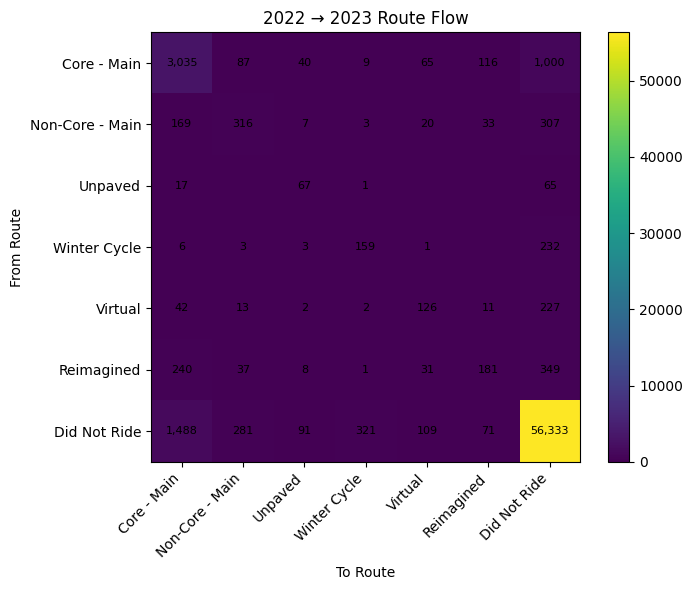

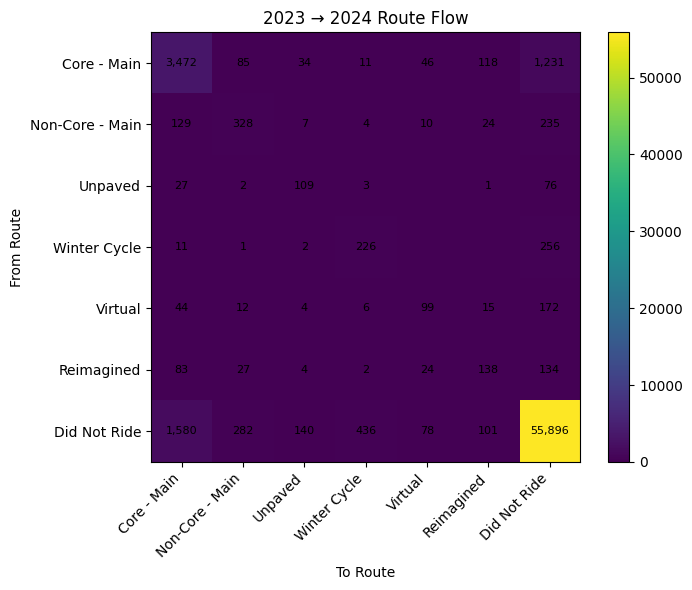

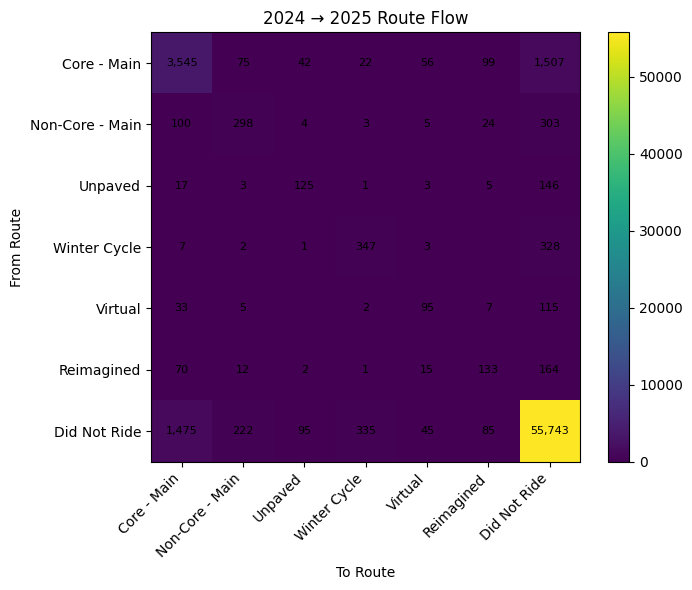

In [ ]:
def plot_route_flow_heatmap(trans_matrix, title):
    """
    Plot a route flow heatmap from a transition matrix.
    """
    data = trans_matrix.loc[route_order, route_order].values

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(data)

    # Axis ticks & labels
    ax.set_xticks(range(len(route_order)))
    ax.set_xticklabels(route_order, rotation=45, ha="right")
    ax.set_yticks(range(len(route_order)))
    ax.set_yticklabels(route_order)

    ax.set_xlabel("To Route")
    ax.set_ylabel("From Route")
    ax.set_title(title)

    # Annotate counts in each cell
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if val > 0:
                ax.text(
                    j, i,
                    f"{int(val):,}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Plot the three heatmaps
plot_route_flow_heatmap(route_flow_22_23, "2022 → 2023 Route Flow")
plot_route_flow_heatmap(route_flow_23_24, "2023 → 2024 Route Flow")
plot_route_flow_heatmap(route_flow_24_25, "2024 → 2025 Route Flow")


# Return Probability Analysis

In [ ]:
import numpy as np
import pandas as pd

# =========================================================
# WIN-BACK ANALYSIS: AGGREGATE RETURN PROBABILITIES
# =========================================================
# Assumes df_ry exists with columns:
#   - "Main_ID": rider identifier
#   - "EventYear": year of participation
# =========================================================

# ---------------------------------------------------------
# 1) Build participation matrix: rows = rider, cols = year
# ---------------------------------------------------------
win_participation = pd.crosstab(
    df_ry["Main_ID"],
    df_ry["EventYear"]
)

# Convert to 0/1 participation
win_participation = (win_participation > 0).astype(int)

win_years = sorted(win_participation.columns.tolist())
win_max_year = max(win_years)

print("Win-back module: years in matrix =", win_years[:5], "...", win_years[-5:])
print("Total riders in matrix:", win_participation.shape[0])

# ---------------------------------------------------------
# 2) Count churn events and returns with gaps (aggregate)
# ---------------------------------------------------------
# Definition:
#   - A "churn event" happens when a rider goes from 1→0 between two years,
#     or after their final active year if that year < max_year.
#   - A "win-back" event is a churn that is followed by a return
#     after `gap` full years off (gap >= 1).

win_total_churn_events = 0            # denominator for probabilities
win_gap_counts_dict   = {}            # gap_length -> number of returns after that gap

for _, row in win_participation.iterrows():
    # years this rider rode
    active = [y for y in win_years if row[y] == 1]
    if len(active) == 0:
        continue

    # Look at each pair of consecutive active years
    for i in range(len(active) - 1):
        y_last = active[i]
        y_next = active[i + 1]
        gap = y_next - y_last - 1

        if gap > 0:
            # Rider rode in y_last, then stopped, then returned in y_next
            # This is one churn event with a return after `gap` years off.
            win_total_churn_events += 1
            win_gap_counts_dict[gap] = win_gap_counts_dict.get(gap, 0) + 1
        else:
            # gap == 0 → rode consecutive years, no churn between these years
            continue

    # After their final active year, if it's not the max year,
    # treat as a churn with no observed return (right-censored).
    if active[-1] < win_max_year:
        win_total_churn_events += 1

print("Total churn events (aggregate):", win_total_churn_events)

# ---------------------------------------------------------
# 3) Exact & cumulative return probabilities by gap length
# ---------------------------------------------------------

# Convert gap_counts_dict to a sorted Series
if len(win_gap_counts_dict) == 0:
    raise ValueError("No win-back events found in data; check df_ry or year range.")

win_gap_counts_ser = pd.Series(win_gap_counts_dict).sort_index()
win_gap_counts_ser.name = "ReturnedCount"

# Unconditional P(return after exactly g years off | churned)
win_return_prob_exact = (win_gap_counts_ser / win_total_churn_events).rename("ProbReturnExact")

# Unconditional P(return within ≤ g years off | churned)
win_return_prob_cum = win_return_prob_exact.cumsum().rename("ProbReturnCumulative")

# Combine into a single table
win_aggregate_return_probs = pd.concat(
    [win_return_prob_exact, win_return_prob_cum],
    axis=1
)

display(win_aggregate_return_probs)

# Fraction of churners who ever return within the observed horizon
win_R_total = win_return_prob_exact.sum()
print("Fraction of churners who EVER return (within data horizon):", win_R_total)

# ---------------------------------------------------------
# 4) Forward-looking table: "Years gone" → future return odds
# ---------------------------------------------------------
# For a rider who has already been gone g years:
#   - ProbReturnNextYear: P(return in year g+1 | still gone at end of year g)
#   - ProbEverReturnFuture: P(ever returning at ANY future time | still gone at end of year g)

win_hazard_rows = []
win_max_gap = int(win_gap_counts_ser.index.max())

for g0 in range(0, win_max_gap + 1):
    # YearsGone = g0 (they have been absent for g0 full years)
    # Next year corresponds to gap = g0 + 1

    # Unconditional mass of returns up to and including gap g0
    if g0 > 0:
        past_mass = win_return_prob_exact[win_return_prob_exact.index <= g0].sum()
    else:
        past_mass = 0.0

    # Fraction of churners who have NOT returned by end of year g0
    # (includes those who will return later AND those who never return)
    S_raw = 1.0 - past_mass

    if S_raw <= 0:
        next_year_prob   = np.nan
        ever_again_prob  = np.nan
    else:
        # Unconditional probability mass of returning exactly at gap g0+1
        mass_next = win_return_prob_exact.get(g0 + 1, 0.0)

        # Conditional: P(return at g0+1 | still gone at g0)
        next_year_prob = mass_next / S_raw

        # Unconditional mass of returns at gaps > g0
        future_return_mass = win_R_total - past_mass

        # Conditional: P(ever return at ANY future time | still gone at g0)
        ever_again_prob = future_return_mass / S_raw

    win_hazard_rows.append({
        "YearsGone": g0,
        "ProbReturnNextYear": next_year_prob,
        "ProbEverReturnFuture": ever_again_prob,
    })

win_return_hazard_table = pd.DataFrame(win_hazard_rows)

display(win_return_hazard_table)


Win-back module: years in matrix = [1980, 1981, 1982, 1983, 1984] ... [2021, 2022, 2023, 2024, 2025]
Total riders in matrix: 45746
Total churn events (aggregate): 51913


,ProbReturnExact,ProbReturnCumulative
1,0.136998,0.136998
2,0.042706,0.179705
3,0.022769,0.202473
4,0.013927,0.216401
5,0.009786,0.226186
6,0.007224,0.233410
7,0.005105,0.238514
8,0.004142,0.242656
9,0.003756,0.246412
10,0.002581,0.248994


Fraction of churners who EVER return (within data horizon): 0.2611484599233333


,YearsGone,ProbReturnNextYear,ProbEverReturnFuture
0,0,0.136998,0.261148
1,1,0.049486,0.143858
2,2,0.027757,0.099286
3,3,0.017463,0.073571
4,4,0.012488,0.057106
5,5,0.009335,0.045182
6,6,0.006659,0.036185
7,7,0.005439,0.029724
8,8,0.004960,0.024418
9,9,0.003425,0.019555


##### Excel creator

In [ ]:
output_path = "PMC_full_retention_and_LTV.xlsx"

blank = pd.DataFrame({"": []})

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:

    # -------------------------
    # SECTION 1: RETENTION
    # -------------------------
    blank.to_excel(writer, sheet_name="--- Retention ---", index=False)

    global_retention.to_excel(writer,   sheet_name="GlobalRetention",         index=False)
    main_retention.to_excel(writer,     sheet_name="MainWeekendRetention",    index=False)
    core_retention.to_excel(writer,     sheet_name="CoreWeekendRetention",    index=False)
    noncore_retention.to_excel(writer,  sheet_name="NonCoreWeekendRetention", index=False)
    unpaved_retention.to_excel(writer,  sheet_name="UnpavedRetention",        index=False)
    winter_retention.to_excel(writer,   sheet_name="WinterRetention",         index=False)
    virtual_retention.to_excel(writer,  sheet_name="VirtualRetention",        index=False)
    reimagined_retention.to_excel(writer, sheet_name="ReimaginedRetention",   index=False)

    participation_overview.to_excel(writer, sheet_name="ParticipationOverview")
    participation_metrics.to_excel(writer,  sheet_name="ParticipationMetrics")
    route_participation.to_excel(writer,    sheet_name="RouteParticipation")


    # ----------------------------
    # SECTION 2: COHORTS & SURVIVAL (GLOBAL)
    # ----------------------------
    blank.to_excel(writer, sheet_name="--- Cohorts_LTV_Global ---", index=False)

    cohort_tenure_counts.to_excel(writer,   sheet_name="Counts_CohortTenure")
    cohort_tenure_funds.to_excel(writer,    sheet_name="Funds_CohortTenure")
    avg_fundraising_tenure.to_excel(writer, sheet_name="AvgFunds_CohortTenure")

    marginal_retention.to_excel(writer, sheet_name="Ret_Part_Marginal")
    base_retention.to_excel(writer,     sheet_name="Ret_Part_Base")

    dollar_marginal.to_excel(writer, sheet_name="Ret_Dollar_Marginal")
    dollar_base.to_excel(writer,     sheet_name="Ret_Dollar_Base")

    survival_participation.to_excel(writer, sheet_name="Survival_Part",   index=False)
    survival_dollars.to_excel(writer,      sheet_name="Survival_Dollar", index=False)


    # ----------------------------
    # SECTION 3: GLOBAL LTV TABLES
    # ----------------------------
    blank.to_excel(writer, sheet_name="--- LTV_Global ---", index=False)

    ltv_global_full_base.to_excel(writer,   sheet_name="LTV_Global_FullHistory", index=False)
    ltv_global_modern.to_excel(writer,      sheet_name="LTV_Global_2005plus",    index=False)

    # ----------------------------
    # SECTION 4: MAIN WEEKEND COHORTS & LTV
    # ----------------------------
    blank.to_excel(writer, sheet_name="--- LTV_MainWeekend ---", index=False)

    cohort_tenure_counts_main.to_excel(writer,   sheet_name="Counts_CohortTenure_Main")
    cohort_tenure_funds_main.to_excel(writer,    sheet_name="Funds_CohortTenure_Main")
    avg_fundraising_tenure_main.to_excel(writer, sheet_name="AvgFunds_CohortTenure_Main")

    ltv_main_full_base.to_excel(writer,   sheet_name="LTV_Main_FullHistory", index=False)
    ltv_main_modern.to_excel(writer,      sheet_name="LTV_Main_2005plus",    index=False)

    # ----------------------------
    # SECTION 5: LTV SUMMARY OUTPUT
    # ----------------------------
    ltv_output.to_excel(writer, sheet_name="LTV_Output", index=False)

    # ----------------------------
    # SECTION 6: RIDER COMPOSITION
    # ----------------------------

    # --- 2025 Rider Composition & Age × Tenure ---
    # 2025 Rider composition card
    rider_composition_2025.to_excel(
        writer,
        sheet_name="Rider_Composition_2025",
        index=False
    )

    # Age × Tenure composition – Core and Global
    core_part_table.to_excel(writer,  sheet_name="Core25_Counts",      index=True)
    core_fund_table.to_excel(writer,  sheet_name="Core25_Funds2025",   index=True)
    glob_part_table.to_excel(writer,  sheet_name="Global25_Counts",    index=True)
    glob_fund_table.to_excel(writer,  sheet_name="Global25_Funds2025", index=True)


    # Route flow transition matrices (for heatmaps)
    route_flow_22_23.to_excel(writer, sheet_name="RouteFlow_2022_2023")
    route_flow_23_24.to_excel(writer, sheet_name="RouteFlow_2023_2024")
    route_flow_24_25.to_excel(writer, sheet_name="RouteFlow_2024_2025")

    # -------------------------------------------------------
    # SECTION X: WIN-BACK ANALYSIS
    # -------------------------------------------------------
    win_aggregate_return_probs.to_excel(
        writer,
        sheet_name="Winback_Return_Aggregate",
        index=True
    )

    win_return_hazard_table.to_excel(
        writer,
        sheet_name="Winback_Return_Conditional",
        index=False
    )

print("Saved:", output_path)


Saved: PMC_full_retention_and_LTV.xlsx


#### Cohort & Retention for Excel

In [ ]:
# Run Export to Excel of above document

from google.colab import files
files.download("PMC_full_retention_and_LTV.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Raw segment matrix full -- not necessary to interact with
# with pd.ExcelWriter("PMC_participation_matrices.xlsx", engine="xlsxwriter") as writer:
#    seg_matrix.to_excel(writer, sheet_name="SegMatrix")
#    global_participation.to_excel(writer, sheet_name="GlobalParticipation")

# from google.colab import files
# files.download("PMC_participation_matrices.xlsx")

# Data Point Backups




#### EV vs. 1-and-done

In [ ]:
# CONFIG
COHORT_MIN_YEAR = 2005  # modern era
TENURE_COL = "Tenure"   # for global analysis; use "Tenure_Main" for Main Weekend

# df_ry should already have: Main_ID, EventYear, CohortYear, Tenure, FUNDRAISING_COL

# 1. Filter to modern-era cohorts
df_ry_modern = df_ry[df_ry["CohortYear"] >= COHORT_MIN_YEAR].copy()

# 2. Compute lifetime stats per rider
rider_lifetime = (
    df_ry_modern
    .groupby("Main_ID")
    .agg(
        CohortYear=("CohortYear", "min"),
        MaxTenure=(TENURE_COL, "max"),
        LifetimeFunds=(FUNDRAISING_COL, "sum"),
    )
    .reset_index()
)

# 3. Split into one-and-done vs reach-2+
one_and_done = rider_lifetime[rider_lifetime["MaxTenure"] == 1].copy()
reach_two_plus = rider_lifetime[rider_lifetime["MaxTenure"] >= 2].copy()

# 4. Compute averages
one_and_done_avg = one_and_done["LifetimeFunds"].mean()
reach_two_plus_avg = reach_two_plus["LifetimeFunds"].mean()

# 5. Multiplier
multiplier = reach_two_plus_avg / one_and_done_avg if one_and_done_avg else np.nan

print("Modern era (cohorts >= 2005) – Global")
print("Riders (one-and-done):", len(one_and_done))
print("Riders (reach >=2):   ", len(reach_two_plus))
print("Avg lifetime funds | one-and-done:", one_and_done_avg)
print("Avg lifetime funds | reach >=2:   ", reach_two_plus_avg)
print("Multiplier (reach>=2 vs one-and-done):", multiplier)


#### Main Weekend Year 2 vs. one-and-done

In [ ]:
COHORT_MIN_YEAR = 2005
TENURE_COL = "Tenure_Main"

df_main_modern = df_ry_main[df_ry_main["CohortYear_Main"] >= COHORT_MIN_YEAR].copy()

rider_lifetime_main = (
    df_main_modern
    .groupby("Main_ID")
    .agg(
        CohortYear_Main=("CohortYear_Main", "min"),
        MaxTenure_Main=(TENURE_COL, "max"),
        LifetimeFunds_Main=(FUNDRAISING_COL, "sum"),
    )
    .reset_index()
)

one_and_done_main = rider_lifetime_main[rider_lifetime_main["MaxTenure_Main"] == 1].copy()
reach_two_plus_main = rider_lifetime_main[rider_lifetime_main["MaxTenure_Main"] >= 2].copy()

one_and_done_avg_main = one_and_done_main["LifetimeFunds_Main"].mean()
reach_two_plus_avg_main = reach_two_plus_main["LifetimeFunds_Main"].mean()
multiplier_main = reach_two_plus_avg_main / one_and_done_avg_main if one_and_done_avg_main else np.nan

print("Modern era (cohorts >= 2005) – Main Weekend")
print("Riders (one-and-done):", len(one_and_done_main))
print("Riders (reach >=2):   ", len(reach_two_plus_main))
print("Avg lifetime funds | one-and-done:", one_and_done_avg_main)
print("Avg lifetime funds | reach >=2:   ", reach_two_plus_avg_main)
print("Multiplier (reach>=2 vs one-and-done):", multiplier_main)


# Survivorship Curves

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_cohort_survival(
    df: pd.DataFrame,
    tenure_col: str,
    cohort_col: str,
    value_col: str,
    title: str,
    ylabel: str,
):
    """
    Plots cohort survival curves (one line per cohort) with:
      - all cohorts as thin, semi-transparent lines
      - the cross-cohort median survival as a thick highlighted line

    df: long-form DataFrame with one row per cohort-tenure combination.
    tenure_col: name of the tenure column (e.g. "Tenure")
    cohort_col: name of the cohort column (e.g. "CohortYear")
    value_col: name of the survival/value column to plot (e.g. "Survival_Participation")
    """

    # Pivot to Tenure x Cohort matrix
    wide = df.pivot_table(
        index=tenure_col,
        columns=cohort_col,
        values=value_col,
        aggfunc="mean"
    ).sort_index()

    # Median across cohorts at each tenure
    median_curve = wide.median(axis=1, skipna=True)

    plt.figure(figsize=(10, 5))

    # Plot each cohort (faded)
    for cohort in wide.columns:
        plt.plot(
            wide.index,
            wide[cohort],
            linewidth=0.8,
            alpha=0.25,   # faded lines
        )

    # Plot median curve (emphasized)
    plt.plot(
        median_curve.index,
        median_curve.values,
        linewidth=2.5,
        linestyle="-",
        label="Median Cohort",
    )

    plt.title(title)
    plt.xlabel("Tenure (Years Since First Ride)")
    plt.ylabel(ylabel)
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.legend()
    plt.ylim(0, 1.05)  # for survival / index curves

    plt.tight_layout()
    plt.show()


#### Participation Survival Curve

In [ ]:
# cohort_tenure_counts: index = CohortYear, columns = Tenure, values = rider counts

# 1. Ensure sorted
counts = cohort_tenure_counts.sort_index()

# 2. Survival = count at tenure t / count at tenure 1, per cohort
survival_matrix = counts.div(counts[1], axis=0)

# 3. Long-form: CohortYear, Tenure, BaseSurvival
survival_participation_long = (
    survival_matrix
    .stack()
    .rename("BaseSurvival")
    .reset_index()
)

# Rename columns defensively in case index name is something odd
survival_participation_long = survival_participation_long.rename(
    columns={
        survival_participation_long.columns[0]: "CohortYear",
        survival_participation_long.columns[1]: "Tenure",
    }
)

print(survival_participation_long.head())


In [ ]:
plot_cohort_survival(
    df=survival_participation_long,
    tenure_col="Tenure",
    cohort_col="CohortYear",
    value_col="BaseSurvival",
    title="Rider Participation Survival by Cohort",
    ylabel="Participation Survival (P(T = t | T = 1))",
)


#### Fundraising Survival Curve

In [ ]:
# cohort_tenure_funds: index = CohortYear, columns = Tenure, values = total funds

funds = cohort_tenure_funds.sort_index()

# Dollar survival index vs tenure 1
dollar_survival_matrix = funds.div(funds[1], axis=0)

survival_dollars_long = (
    dollar_survival_matrix
    .stack()
    .rename("DollarBaseIndex")
    .reset_index()
)

survival_dollars_long = survival_dollars_long.rename(
    columns={
        survival_dollars_long.columns[0]: "CohortYear",
        survival_dollars_long.columns[1]: "Tenure",
    }
)

plot_cohort_survival(
    df=survival_dollars_long,
    tenure_col="Tenure",
    cohort_col="CohortYear",
    value_col="DollarBaseIndex",
    title="Fundraising Survival by Cohort",
    ylabel="Fundraising Survival Index (vs Tenure 1)",
)


In [ ]:
survival_dollars.columns

In [ ]:
## Modern-era participation survival by cohort

In [ ]:
MODERN_START = 2005

counts_modern = cohort_tenure_counts.loc[
    cohort_tenure_counts.index >= MODERN_START
].sort_index()

# IMPORTANT: do NOT fill missing tenures with 0 — leave as NaN
survival_matrix_modern = counts_modern.div(counts_modern[1], axis=0)

# Preserve NaNs (meaning: cohort hasn't reached that tenure)
survival_participation_long_modern = (
    survival_matrix_modern
    .stack(dropna=True)         # <--- remove NaN rows entirely
    .rename("BaseSurvival")
    .reset_index()
)

survival_participation_long_modern = survival_participation_long_modern.rename(
    columns={
        survival_participation_long_modern.columns[0]: "CohortYear",
        survival_participation_long_modern.columns[1]: "Tenure",
    }
)


In [ ]:
plot_cohort_survival(
    df=survival_participation_long_modern,
    tenure_col="Tenure",
    cohort_col="CohortYear",
    value_col="BaseSurvival",
    title="Rider Participation Survival by Cohort (Modern Era, ≥2005)",
    ylabel="Participation Survival (P(T = t | T = 1))",
    plt.xlim(1, 21)     # Force x-axis to show 1 → 21 years only
)


In [ ]:
participation_median_table = (
    survival_participation_long_modern
    .groupby("Tenure")["BaseSurvival"]
    .median()
    .reindex(range(1, 22))             # explicitly Tenure 1 → 21
    .rename("MedianParticipationSurvival")
    .reset_index()
)

display(participation_median_table)


## Modern dollar survival by cohort

In [ ]:
MODERN_START = 2005

# Funds for the same modern cohorts
funds_modern = cohort_tenure_funds.loc[
    cohort_tenure_funds.index >= MODERN_START
].sort_index()

# Use the same valid tenures (where any riders exist)
funds_modern = funds_modern[valid_tenures]

dollar_survival_matrix_modern = funds_modern.div(funds_modern[1], axis=0)

survival_dollars_long_modern = (
    dollar_survival_matrix_modern
    .stack(dropna=True)
    .rename("DollarBaseIndex")
    .reset_index()
)

survival_dollars_long_modern = survival_dollars_long_modern.rename(
    columns={
        survival_dollars_long_modern.columns[0]: "CohortYear",
        survival_dollars_long_modern.columns[1]: "Tenure",
    }
)


In [ ]:
plot_cohort_survival(
    df=survival_dollars_long_modern,
    tenure_col="Tenure",
    cohort_col="CohortYear",
    value_col="DollarBaseIndex",
    title="Fundraising Survival by Cohort (Modern Era, ≥2005)",
    ylabel="Fundraising Survival Index (vs Tenure 1)",
    plt.xlim(1, 21)     # Force x-axis to show 1 → 21 years only
)


In [ ]:
dollar_median_table = (
    survival_dollars_long_modern
    .groupby("Tenure")["DollarBaseIndex"]
    .median()
    .reindex(range(1, 22))             # explicitly Tenure 1 → 21
    .rename("MedianDollarSurvival")
    .reset_index()
)

display(dollar_median_table)
